In [1]:
pip install moex-store pandas numpy matplotlib statsmodels linearmodels


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [linearmodels]0m 6/7 [linearmodels]
Note: you may need to restart the kernel to use updated packages.


In [163]:
import requests
import pandas as pd
from datetime import datetime
import time

def get_daily_history(secid, start, end):
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/{secid}.json"
    params = {'from': start, 'till': end, 'limit': 10000}
    try:
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
        data = r.json()
        cols = data['history']['columns']
        rows = data['history']['data']
        df = pd.DataFrame(rows, columns=cols)
        if df.empty:
            return pd.DataFrame()
        # оставляем нужные колонки
        df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
        df = df[['TRADEDATE', 'CLOSE', 'VOLUME']].rename(columns={'TRADEDATE': 'date', 'CLOSE': 'close', 'VOLUME': 'volume'})
        df['close'] = pd.to_numeric(df['close'], errors='coerce')
        df['volume'] = pd.to_numeric(df['volume'], errors='coerce')
        return df
    except Exception as e:
        print(f"Failed {secid}: {e}")
        return pd.DataFrame()

# Загружаем
daily = {}
for ticker in tickers:
    print(ticker)
    df = get_daily_history(ticker, start, end)
    if not df.empty:
        daily[ticker] = df
    time.sleep(0.2)

VTBR
SBER
FEES
TRNFP
HYDR


In [376]:
!pip install moex-store pandas numpy statsmodels linearmodels requests beautifulsoup4 lxml


In [377]:
# Если чего-то нет, установите: !pip install moex-store pandas numpy statsmodels linearmodels requests beautifulsoup4 lxml
import pandas as pd
import numpy as np
import requests
from datetime import datetime
import time
import warnings
warnings.filterwarnings('ignore')

In [378]:
import pandas as pd
import numpy as np
import requests
import time

# Функция загрузки с пагинацией
def get_complete_history(secid, start, end):
    all_data = []
    offset = 0
    limit = 100
    while True:
        url = f"https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/{secid}.json"
        params = {'from': start, 'till': end, 'limit': limit, 'start': offset}
        try:
            r = requests.get(url, params=params, timeout=15)
            r.raise_for_status()
            data = r.json()
            if 'history' not in data or not data['history']['data']:
                break
            cols = data['history']['columns']
            rows = data['history']['data']
            df = pd.DataFrame(rows, columns=cols)
            if df.empty:
                break
            df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
            df = df[['TRADEDATE', 'CLOSE', 'VOLUME']].rename(columns={'TRADEDATE': 'date', 'CLOSE': 'close', 'VOLUME': 'volume'})
            df['close'] = pd.to_numeric(df['close'], errors='coerce')
            df['volume'] = pd.to_numeric(df['volume'], errors='coerce')
            all_data.append(df)
            offset += limit
            if len(rows) < limit:
                break
        except Exception as e:
            print(f"Error {secid}: {e}")
            break
        time.sleep(0.1)
    if not all_data:
        return pd.DataFrame()
    return pd.concat(all_data, ignore_index=True)

# Финальный список тикеров (без RSTI)
final_tickers = [
    'SBER', 'GAZP', 'LKOH', 'GMKN', 'VTBR', 'MGNT', 'ROSN', 'SNGS', 'MTSS', 'CHMF',
    'NVTK', 'TATN', 'URKA', 'ALRS', 'MOEX', 'TRNFP', 'HYDR', 'MAGN', 'NLMK', 'FEES',
    'RTKM', 'AFLT'
]

start_date = '2015-01-01'
end_date = '2025-12-31'

daily_data = {}
for ticker in final_tickers:
    print(f"Loading {ticker}...")
    df = get_complete_history(ticker, start_date, end_date)
    if not df.empty:
        daily_data[ticker] = df
    time.sleep(0.2)
print("All data loaded.")

Loading SBER...
Loading GAZP...
Loading LKOH...
Loading GMKN...
Loading VTBR...
Loading MGNT...
Loading ROSN...
Loading SNGS...
Loading MTSS...
Loading CHMF...
Loading NVTK...
Loading TATN...
Loading URKA...
Loading ALRS...
Loading MOEX...
Loading TRNFP...
Loading HYDR...
Loading MAGN...
Loading NLMK...
Loading FEES...
Loading RTKM...
Loading AFLT...
All data loaded.


In [379]:
# Месячные данные
monthly = {}
full_monthly_index = pd.date_range(start='2015-01-31', end='2025-12-31', freq='M')
for ticker, df in daily_data.items():
    df = df.sort_values('date').set_index('date')
    monthly_price = df['close'].resample('M').last()
    monthly_volume = df['volume'].resample('M').sum()
    monthly_price = monthly_price.reindex(full_monthly_index)
    monthly_volume = monthly_volume.reindex(full_monthly_index)
    mdf = pd.DataFrame({'close': monthly_price, 'volume': monthly_volume})
    mdf['return'] = mdf['close'].pct_change()
    mdf = mdf.dropna(subset=['close'])
    monthly[ticker] = mdf

In [380]:
print(mdf)

            close      volume    return
2015-01-31  38.25    72705600       NaN
2015-02-28  39.19    85975000  0.024575
2015-03-31  34.00    84326600 -0.132432
2015-04-30  38.15   132232500  0.122059
2015-05-31  41.10    75574500  0.077326
...           ...         ...       ...
2025-08-31  62.21  1207605820  0.091787
2025-09-30  54.34   582117440 -0.126507
2025-10-31  50.45   704299320 -0.071586
2025-11-30  57.32   632771720  0.136174
2025-12-31  57.95   692246290  0.010991

[132 rows x 3 columns]


In [381]:
# Будущие доходности
for ticker, df in monthly.items():
    df['fwd_3m'] = df['close'].shift(-3) / df['close'] - 1
    df['fwd_12m'] = df['close'].shift(-12) / df['close'] - 1
    df['fwd_36m'] = df['close'].shift(-36) / df['close'] - 1
    monthly[ticker] = df

In [382]:
print(df)

            close      volume    return    fwd_3m   fwd_12m   fwd_36m
2015-01-31  38.25    72705600       NaN -0.002614  0.320261  2.484967
2015-02-28  39.19    85975000  0.024575  0.048737  0.457004  2.609339
2015-03-31  34.00    84326600 -0.132432  0.124706  1.190588  3.576471
2015-04-30  38.15   132232500  0.122059  0.031455  1.030931  2.774574
2015-05-31  41.10    75574500  0.077326 -0.026764  0.987835  2.425791
...           ...         ...       ...       ...       ...       ...
2025-08-31  62.21  1207605820  0.091787 -0.078605       NaN       NaN
2025-09-30  54.34   582117440 -0.126507  0.066434       NaN       NaN
2025-10-31  50.45   704299320 -0.071586       NaN       NaN       NaN
2025-11-30  57.32   632771720  0.136174       NaN       NaN       NaN
2025-12-31  57.95   692246290  0.010991       NaN       NaN       NaN

[132 rows x 6 columns]


In [383]:
# Рыночные факторы (волатильность, средний объём)
daily_ret = {}
for ticker in final_tickers:
    df = daily_data[ticker].copy().sort_values('date')
    df['daily_ret'] = df['close'].pct_change()
    df['log_volume'] = np.log(df['volume'] + 1)
    daily_ret[ticker] = df

In [384]:
print(df)

           date  close    volume  daily_ret  log_volume
0    2015-01-05  33.21    982200        NaN   13.797551
1    2015-01-06  33.07    768000  -0.004216   13.551546
2    2015-01-08  35.17   3377000   0.063502   15.032499
3    2015-01-09  34.00   4286300  -0.033267   15.270935
4    2015-01-12  34.45   2852900   0.013235   14.863847
...         ...    ...       ...        ...         ...
2776 2025-12-24  57.87  17342010  -0.003959   16.668642
2777 2025-12-25  56.90  13100340  -0.016762   16.388149
2778 2025-12-26  58.85  34307720   0.034271   17.350881
2779 2025-12-29  57.91  43612240  -0.015973   17.590848
2780 2025-12-30  57.95  14172230   0.000691   16.466795

[2781 rows x 5 columns]


In [385]:
for ticker, dfm in monthly.items():
    dfd = daily_ret[ticker].copy()
    dates = dfm.index
    vol_list = []
    avg_vol_list = []
    for d in dates:
        start_day = d - pd.DateOffset(months=12)
        mask = (dfd['date'] >= start_day) & (dfd['date'] <= d)
        daily_slice = dfd.loc[mask]
        if len(daily_slice) > 20:
            vol = daily_slice['daily_ret'].std() * np.sqrt(252)
        else:
            vol = np.nan
        start_vol = d - pd.DateOffset(months=3)
        mask_vol = (dfd['date'] >= start_vol) & (dfd['date'] <= d)
        vol_slice = dfd.loc[mask_vol]
        avg_vol = vol_slice['log_volume'].mean() if not vol_slice.empty else np.nan
        vol_list.append(vol)
        avg_vol_list.append(avg_vol)
    dfm['volatility'] = vol_list
    dfm['avg_log_volume'] = avg_vol_list
    monthly[ticker] = dfm

# Проверка
print("SBER shape:", monthly['SBER'].shape)
print("SBER tail:\n", monthly['SBER'][['close', 'fwd_12m']].tail(5))

SBER shape: (132, 8)
SBER tail:
              close  fwd_12m
2025-08-31  310.04      NaN
2025-09-30  288.36      NaN
2025-10-31  291.89      NaN
2025-11-30  304.17      NaN
2025-12-31  299.90      NaN


In [386]:
import pandas as pd
import numpy as np
import re
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

# Путь к файлу
file_path = 'Term paper_Kasyanov (1).xlsx'

# Читаем список тикеров из листа 'Stocks'
stocks_df = pd.read_excel(file_path, sheet_name='Stocks', header=None)
tickers_from_excel = stocks_df.iloc[1:, 0].dropna().tolist()
print("Тикеры в Excel:", tickers_from_excel)

Тикеры в Excel: ['SBER', 'GAZP', 'LKOH', 'GMKN', 'VTBR', 'MGNT', 'ROSN', 'SNGS', 'MTSS', 'CHMF', 'NVTK', 'TATN', 'URKA', 'ALRS', 'MOEX', 'TRNFP', 'HYDR', 'MAGN', 'NLMK', 'FEES', 'RTKM', 'AFLT']


In [387]:
all_fundamentals = []

for ticker in tickers_from_excel:
    try:
        df = pd.read_excel(file_path, sheet_name=ticker, header=None)
    except Exception as e:
        print(f"Не удалось прочитать лист {ticker}: {e}")
        continue
    
    # Первая строка: годы
    years = df.iloc[0, 1:].values
    # Вторая строка: ROE
    roe_row = df.iloc[1, 1:].values
    # Третья строка: P/B
    pb_row = df.iloc[2, 1:].values
    # Четвертая строка: D/E
    de_row = df.iloc[3, 1:].values
    # Пятая строка: D/Y
    dy_row = df.iloc[4, 1:].values
    
    for i, year in enumerate(years):
        # Пропускаем, если год не число
        try:
            y = int(year)
        except:
            continue
        
        pb = clean_value(pb_row[i])
        roe = clean_value(roe_row[i])
        de = clean_value(de_row[i])
        dy = clean_value(dy_row[i])
        
        # Пропускаем, если нет ключевых переменных (pb, roe)
        if pd.isna(pb) or pd.isna(roe):
            continue
        
        all_fundamentals.append({
            'ticker': ticker,
            'year': y,
            'pb': pb,
            'roe': roe,
            'de': de,
            'dy': dy
        })

fund_df = pd.DataFrame(all_fundamentals)
print(f"Собрано {len(fund_df)} строк")
fund_df.head()

Собрано 202 строк


,ticker,year,pb,roe,de,dy
0,SBER,2015,0.95,0.102,10.52,NaN
1,SBER,2016,1.42,0.208,8.29,0.040
2,SBER,2017,1.47,0.242,6.89,0.056
3,SBER,2018,1.09,0.231,7.09,0.064
4,SBER,2019,1.28,0.222,5.69,0.082


In [388]:
fundamental_long = []
for _, row in fund_df.iterrows():
    ticker = row['ticker']
    year = row['year']
    # Применяем данные за год к месяцам с июля по июнь следующего года
    start_month = pd.Timestamp(f'{year}-07-01')
    end_month = pd.Timestamp(f'{year+1}-06-30')
    months = pd.date_range(start=start_month, end=end_month, freq='M')
    for month in months:
        fundamental_long.append({
            'ticker': ticker,
            'date': month,
            'pb': row['pb'],
            'roe': row['roe'],
            'de': row['de'],
            'dy': row['dy']
        })

fund_long_df = pd.DataFrame(fundamental_long)
print(f"Создано {len(fund_long_df)} строк для объединения")

Создано 2424 строк для объединения


In [389]:
monthly_list = []
for ticker, df in monthly.items():
    df = df.reset_index().rename(columns={'index': 'date'})
    df['ticker'] = ticker
    monthly_list.append(df)
monthly_df = pd.concat(monthly_list, ignore_index=True)
monthly_df['date'] = pd.to_datetime(monthly_df['date'])
print("Размер monthly_df:", monthly_df.shape)

Размер monthly_df: (2829, 10)


In [390]:
merged = pd.merge(monthly_df, fund_long_df, on=['ticker', 'date'], how='left')
print("Размер merged:", merged.shape)

Размер merged: (2829, 14)


In [391]:
# Логарифмическая трансформация долга
merged['log_de'] = np.log(1 + merged['de'])
# Квадраты
merged['pb_sq'] = merged['pb'] ** 2
merged['roe_sq'] = merged['roe'] ** 2
merged['log_de_sq'] = merged['log_de'] ** 2
merged['dy_sq'] = merged['dy'] ** 2

# Удаляем строки с пропусками в зависимых переменных и факторах
merged = merged.dropna(subset=['fwd_3m', 'fwd_12m', 'fwd_36m', 'pb', 'roe', 'log_de', 'dy', 'volatility', 'avg_log_volume'])
print("Размер после удаления пропусков:", merged.shape)

# Устанавливаем мультииндекс
merged = merged.set_index(['ticker', 'date'])
merged = merged.sort_index()

Размер после удаления пропусков: (1254, 19)


In [392]:
print("monthly_df exists:", 'monthly_df' in globals())
print("fund_long_df exists:", 'fund_long_df' in globals())

monthly_df exists: True
fund_long_df exists: True


In [393]:
# Слияние
merged = pd.merge(monthly_df, fund_long_df, on=['ticker', 'date'], how='left')
print("Размер merged после слияния:", merged.shape)
print("Колонки:", merged.columns.tolist())

Размер merged после слияния: (2829, 14)
Колонки: ['date', 'close', 'volume', 'return', 'fwd_3m', 'fwd_12m', 'fwd_36m', 'volatility', 'avg_log_volume', 'ticker', 'pb', 'roe', 'de', 'dy']


In [394]:
# Winsorization
factors = ['pb', 'roe', 'de', 'dy', 'volatility', 'avg_log_volume']
def winsorize_series(s, low=0.01, high=0.99):
    l = s.quantile(low)
    h = s.quantile(high)
    return s.clip(l, h)

for col in factors:
    merged[col] = winsorize_series(merged[col])

# Пересчёт
merged['log_de'] = np.log(1 + merged['de'])
merged['roe_sq'] = merged['roe'] ** 2

# Удаление пропусков
merged = merged.dropna(subset=['fwd_3m', 'fwd_12m', 'fwd_36m', 'pb', 'roe', 'log_de', 'dy', 'volatility', 'avg_log_volume'])
print("Размер после удаления пропусков:", merged.shape)

# Установка мультииндекса
merged = merged.set_index(['ticker', 'date']).sort_index()
print("Индекс:", merged.index.names)

Размер после удаления пропусков: (1254, 16)
Индекс: ['ticker', 'date']


In [396]:
# Загрузка ключевой ставки из CSV
import pandas as pd
import numpy as np

# Предполагаем, что файл называется 'Term paper_Kasyanov - Key rate.csv'
key_rate_df = pd.read_csv('Term paper_Kasyanov - Key rate.csv', encoding='utf-8')

# Посмотрим на колонки
print(key_rate_df.columns)
print(key_rate_df.head())

Index(['Месяц, год', 'Значение ставки'], dtype='object')
      Месяц, год Значение ставки
0   Январь, 2015              17
1  Февраль, 2015              15
2     Март, 2015              15
3   Апрель, 2015              14
4      Май, 2015            12,5


In [397]:
# Преобразование: создадим колонку date в формате последний день месяца
# Месяц, год – в виде "Январь, 2015". Преобразуем в datetime.
def parse_month_year(s):
    # s вида "Январь, 2015"
    month_names = {
        'Январь': 1, 'Февраль': 2, 'Март': 3, 'Апрель': 4, 'Май': 5, 'Июнь': 6,
        'Июль': 7, 'Август': 8, 'Сентябрь': 9, 'Октябрь': 10, 'Ноябрь': 11, 'Декабрь': 12
    }
    parts = s.split(', ')
    month = month_names[parts[0]]
    year = int(parts[1])
    return pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)

key_rate_df['date'] = key_rate_df['Месяц, год'].apply(parse_month_year)

# Очистка значений ставки: замена запятой на точку, приведение к float
def clean_rate(val):
    if isinstance(val, str):
        val = val.replace(',', '.')
        return float(val)
    else:
        return float(val)

key_rate_df['cb_rate'] = key_rate_df['Значение ставки'].apply(clean_rate)
# Оставляем нужные колонки
cb_series = key_rate_df[['date', 'cb_rate']].set_index('date')
print(cb_series.head())

            cb_rate
date               
2015-01-31     17.0
2015-02-28     15.0
2015-03-31     15.0
2015-04-30     14.0
2015-05-31     12.5


In [398]:
# Добавляем ставку в merged
# merged должен быть уже создан (после winsorization, с мультииндексом ticker, date)
# В merged индекс состоит из ('ticker', 'date'). Извлечём дату и сопоставим.
merged['cb_rate'] = merged.index.get_level_values('date').map(cb_series['cb_rate'])
# Проверяем пропуски
print("Пропуски cb_rate:", merged['cb_rate'].isna().sum())
# Удаляем строки с пропусками (если есть)
merged = merged.dropna(subset=['cb_rate'])
print("Размер merged после добавления ставки:", merged.shape)

Пропуски cb_rate: 0
Размер merged после добавления ставки: (1254, 15)


In [401]:
# 1. Загрузка данных о нефти
brent_df = pd.read_csv('POILBREUSDM.csv', parse_dates=['observation_date'])
brent_df = brent_df.rename(columns={'observation_date': 'date', 'POILBREUSDM': 'brent'})
brent_df['date'] = brent_df['date'] + pd.offsets.MonthEnd(0)
brent_df = brent_df.set_index('date')
print("Нефть Brent (2015-2025):")
print(brent_df.loc['2015':'2025'].head())

Нефть Brent (2015-2025):
                brent
date                 
2015-01-31  48.933182
2015-02-28  58.254000
2015-03-31  56.524545
2015-04-30  59.826364
2015-05-31  65.193810


In [402]:
# 2. Добавляем в merged (предполагаем, что merged уже существует)
merged['brent'] = merged.index.get_level_values('date').map(brent_df['brent'])

# Проверяем пропуски
print("Пропуски в brent:", merged['brent'].isna().sum())
# Удаляем строки, где нет данных по нефти (если такие есть)
merged = merged.dropna(subset=['brent'])

Пропуски в brent: 0


In [404]:
# Предполагаем, что merged уже существует и имеет мультииндекс (ticker, date)
merged['crisis_2020'] = ((merged.index.get_level_values('date') >= '2020-01-01') & (merged.index.get_level_values('date') <= '2021-12-31')).astype(int)
merged['crisis_2022'] = (merged.index.get_level_values('date') >= '2022-01-01').astype(int)

print(merged[['crisis_2020', 'crisis_2022']].head())

                   crisis_2020  crisis_2022
ticker date                                
AFLT   2016-07-31            0            0
       2016-08-31            0            0
       2016-09-30            0            0
       2016-10-31            0            0
       2016-11-30            0            0


In [406]:
import requests
import pandas as pd
import numpy as np
import time
import statsmodels.api as sm
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

def get_index_monthly(index_code, start, end):
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/index/boards/tqfd/securities/{index_code}.json"
    params = {'from': start, 'till': end, 'limit': 10000}
    r = requests.get(url, params=params)
    data = r.json()
    cols = data['history']['columns']
    rows = data['history']['data']
    df = pd.DataFrame(rows, columns=cols)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df = df[['TRADEDATE', 'CLOSE']].rename(columns={'TRADEDATE': 'date', 'CLOSE': 'close'})
    df['close'] = pd.to_numeric(df['close'])
    df = df.set_index('date').resample('M').last()
    df['return'] = df['close'].pct_change()
    return df

df_imoex = get_index_monthly('IMOEX', '2015-01-01', '2025-12-31')
df_rgbi = get_index_monthly('RGBI', '2015-01-01', '2025-12-31')

# Месячная безрисковая ставка (приближённо 7% годовых)
rf_monthly = 0.0058

In [407]:
merged_flat = merged.reset_index()  # теперь колонки 'ticker', 'date', и все остальные

In [408]:
merged_flat['score_3m'] = -merged_flat['roe'] + merged_flat['log_de'] - merged_flat['dy'] + merged_flat['volatility']
merged_flat['score_12m'] = -merged_flat['roe'] + merged_flat['log_de'] + merged_flat['volatility']
merged_flat['score_36m'] = -merged_flat['roe']

In [409]:
def select_top_stocks(df, date, score_col, top_pct=0.3):
    subset = df[df['date'] == date]
    n = max(1, int(top_pct * len(subset)))
    top = subset.nlargest(n, score_col)
    return top['ticker'].tolist()

# ----- 3m (ежемесячная ребалансировка) -----
dates_3m = sorted(merged_flat['date'].unique())
port_returns_3m = []
for d in dates_3m:
    tickers_sel = select_top_stocks(merged_flat, d, 'score_3m')
    sub = merged_flat[(merged_flat['date'] == d) & (merged_flat['ticker'].isin(tickers_sel))]
    ret = sub['fwd_3m'].mean() if not sub.empty else np.nan
    port_returns_3m.append({'date': d, 'eq_return': ret})
df_eq_3m = pd.DataFrame(port_returns_3m).set_index('date')

# ----- 12m (ежегодная ребалансировка в январе) -----
jan_dates = [pd.Timestamp(f'{y}-01-31') for y in range(2015, 2026) if pd.Timestamp(f'{y}-01-31') in merged_flat['date'].values]
port_returns_12m = []
for d in jan_dates:
    tickers_sel = select_top_stocks(merged_flat, d, 'score_12m')
    sub = merged_flat[(merged_flat['date'] == d) & (merged_flat['ticker'].isin(tickers_sel))]
    ret = sub['fwd_12m'].mean() if not sub.empty else np.nan
    port_returns_12m.append({'date': d, 'eq_return': ret})
df_eq_12m = pd.DataFrame(port_returns_12m).set_index('date')

# ----- 36m (ребалансировка раз в 3 года: 2015, 2018, 2021, 2024) -----
rebal_dates_36m = [pd.Timestamp('2015-01-31'), pd.Timestamp('2018-01-31'), pd.Timestamp('2021-01-31'), pd.Timestamp('2024-01-31')]
port_returns_36m = []
for d in rebal_dates_36m:
    if d not in merged_flat['date'].values:
        continue
    tickers_sel = select_top_stocks(merged_flat, d, 'score_36m')
    sub = merged_flat[(merged_flat['date'] == d) & (merged_flat['ticker'].isin(tickers_sel))]
    ret = sub['fwd_36m'].mean() if not sub.empty else np.nan
    port_returns_36m.append({'date': d, 'eq_return': ret})
df_eq_36m = pd.DataFrame(port_returns_36m).set_index('date')

In [410]:
df_rgbi_ret = df_rgbi['return'].rename('rgbi')

df_3m = df_eq_3m.join(df_rgbi_ret, how='inner')
df_3m['port_return'] = 0.8 * df_3m['eq_return'] + 0.2 * df_3m['rgbi']

df_12m = df_eq_12m.join(df_rgbi_ret, how='inner')
df_12m['port_return'] = 0.5 * df_12m['eq_return'] + 0.5 * df_12m['rgbi']

df_36m = df_eq_36m.join(df_rgbi_ret, how='inner')
df_36m['port_return'] = 0.2 * df_36m['eq_return'] + 0.8 * df_36m['rgbi']

In [411]:
# Собираем monthly_df из словаря monthly (который уже содержит fwd_3m, fwd_12m, fwd_36m)
monthly_list = []
for ticker, df in monthly.items():
    df = df.reset_index().rename(columns={'index': 'date'})
    df['ticker'] = ticker
    # Оставляем нужные колонки: дата, тикер, доходности, факторы
    # Убедимся, что колонки с будущими доходностями есть
    required_cols = ['date', 'ticker', 'close', 'return', 'fwd_3m', 'fwd_12m', 'fwd_36m', 
                     'volatility', 'avg_log_volume']
    existing = [c for c in required_cols if c in df.columns]
    monthly_list.append(df[existing])
monthly_df = pd.concat(monthly_list, ignore_index=True)
monthly_df['date'] = pd.to_datetime(monthly_df['date'])
print("monthly_df shape:", monthly_df.shape)
print("Колонки:", monthly_df.columns.tolist())

monthly_df shape: (2829, 9)
Колонки: ['date', 'ticker', 'close', 'return', 'fwd_3m', 'fwd_12m', 'fwd_36m', 'volatility', 'avg_log_volume']


In [412]:
# Предполагаем, что fund_long_df уже создан ранее (из Excel)
merged_new = pd.merge(monthly_df, fund_long_df, on=['ticker', 'date'], how='left')
print("merged_new shape:", merged_new.shape)

merged_new shape: (2829, 13)


In [413]:
# Winsorization (1% и 99%)
factors = ['pb', 'roe', 'de', 'dy', 'volatility', 'avg_log_volume']
def winsorize(s):
    return s.clip(s.quantile(0.01), s.quantile(0.99))
for col in factors:
    merged_new[col] = winsorize(merged_new[col])

merged_new['log_de'] = np.log(1 + merged_new['de'])
merged_new['roe_sq'] = merged_new['roe'] ** 2

# Удаляем пропуски в зависимых переменных и факторах
merged_new = merged_new.dropna(subset=['fwd_3m', 'fwd_12m', 'fwd_36m', 'pb', 'roe', 'log_de', 'dy', 'volatility', 'avg_log_volume'])
print("Размер после удаления пропусков:", merged_new.shape)

Размер после удаления пропусков: (1254, 15)


In [414]:
merged_new['score_3m'] = -merged_new['roe'] + merged_new['log_de'] - merged_new['dy'] + merged_new['volatility']
merged_new['score_12m'] = -merged_new['roe'] + merged_new['log_de'] + merged_new['volatility']
merged_new['score_36m'] = -merged_new['roe']

In [415]:
def select_top_stocks(df, date, score_col, top_pct=0.3):
    subset = df[df['date'] == date]
    if subset.empty:
        return []
    n = max(1, int(top_pct * len(subset)))
    top = subset.nlargest(n, score_col)
    return top['ticker'].tolist()

# 3 месяца (ежемесячно)
dates_3m = sorted(merged_new['date'].unique())
port_returns_3m = []
for d in dates_3m:
    tickers_sel = select_top_stocks(merged_new, d, 'score_3m')
    if not tickers_sel:
        continue
    sub = merged_new[(merged_new['date'] == d) & (merged_new['ticker'].isin(tickers_sel))]
    ret = sub['fwd_3m'].mean()
    port_returns_3m.append({'date': d, 'eq_return': ret})
df_eq_3m = pd.DataFrame(port_returns_3m).set_index('date')

# 12 месяцев (ежегодно в январе)
jan_dates = [pd.Timestamp(f'{y}-01-31') for y in range(2015, 2026) if pd.Timestamp(f'{y}-01-31') in merged_new['date'].values]
port_returns_12m = []
for d in jan_dates:
    tickers_sel = select_top_stocks(merged_new, d, 'score_12m')
    if not tickers_sel:
        continue
    sub = merged_new[(merged_new['date'] == d) & (merged_new['ticker'].isin(tickers_sel))]
    ret = sub['fwd_12m'].mean()
    port_returns_12m.append({'date': d, 'eq_return': ret})
df_eq_12m = pd.DataFrame(port_returns_12m).set_index('date')

# 36 месяцев (ребалансировка раз в 3 года)
rebal_dates = [pd.Timestamp('2015-01-31'), pd.Timestamp('2018-01-31'), pd.Timestamp('2021-01-31'), pd.Timestamp('2024-01-31')]
port_returns_36m = []
for d in rebal_dates:
    if d not in merged_new['date'].values:
        continue
    tickers_sel = select_top_stocks(merged_new, d, 'score_36m')
    if not tickers_sel:
        continue
    sub = merged_new[(merged_new['date'] == d) & (merged_new['ticker'].isin(tickers_sel))]
    ret = sub['fwd_36m'].mean()
    port_returns_36m.append({'date': d, 'eq_return': ret})
df_eq_36m = pd.DataFrame(port_returns_36m).set_index('date')

In [416]:
print("merged_new даты:", merged_new['date'].min(), "->", merged_new['date'].max())
print("Количество уникальных дат в merged_new:", merged_new['date'].nunique())
print("Пример дат:", merged_new['date'].unique()[:10])
print("Даты для 3m ребалансировки (первые 5):", dates_3m[:5])

merged_new даты: 2015-07-31 00:00:00 -> 2022-12-31 00:00:00
Количество уникальных дат в merged_new: 90
Пример дат: <DatetimeArray>
['2016-07-31 00:00:00', '2016-08-31 00:00:00', '2016-09-30 00:00:00',
 '2016-10-31 00:00:00', '2016-11-30 00:00:00', '2016-12-31 00:00:00',
 '2017-01-31 00:00:00', '2017-02-28 00:00:00', '2017-03-31 00:00:00',
 '2017-04-30 00:00:00']
Length: 10, dtype: datetime64[ns]
Даты для 3m ребалансировки (первые 5): [Timestamp('2015-07-31 00:00:00'), Timestamp('2015-08-31 00:00:00'), Timestamp('2015-09-30 00:00:00'), Timestamp('2015-10-31 00:00:00'), Timestamp('2015-11-30 00:00:00')]


In [417]:
print("merged_new shape после dropna:", merged_new.shape)
print("Количество строк с fwd_3m не NaN:", merged_new['fwd_3m'].notna().sum())
print("Количество строк с fwd_12m не NaN:", merged_new['fwd_12m'].notna().sum())
print("Количество строк с fwd_36m не NaN:", merged_new['fwd_36m'].notna().sum())

merged_new shape после dropna: (1254, 18)
Количество строк с fwd_3m не NaN: 1254
Количество строк с fwd_12m не NaN: 1254
Количество строк с fwd_36m не NaN: 1254


In [418]:
# Используем merged_new (после winsorization и очистки)
def select_top_by_factor(df, date, factor, ascending=False, top_pct=0.3):
    subset = df[df['date'] == date].copy()
    if subset.empty:
        return []
    n = max(1, int(top_pct * len(subset)))
    if ascending:
        top = subset.nsmallest(n, factor)
    else:
        top = subset.nlargest(n, factor)
    return top['ticker'].tolist()

# 3m: высокая волатильность
dates_3m = sorted(merged_new['date'].unique())
port_returns_3m = []
for d in dates_3m:
    tickers_sel = select_top_by_factor(merged_new, d, 'volatility', ascending=False)
    if not tickers_sel:
        continue
    sub = merged_new[(merged_new['date'] == d) & (merged_new['ticker'].isin(tickers_sel))]
    ret = sub['fwd_3m'].mean()
    port_returns_3m.append({'date': d, 'eq_return': ret})
df_eq_3m = pd.DataFrame(port_returns_3m).set_index('date')

# 12m: сумма log_de + volatility
merged_new['score_12'] = merged_new['log_de'] + merged_new['volatility']
dates_12m = [pd.Timestamp(f'{y}-01-31') for y in range(2015, 2026) if pd.Timestamp(f'{y}-01-31') in merged_new['date'].values]
port_returns_12m = []
for d in dates_12m:
    tickers_sel = select_top_by_factor(merged_new, d, 'score_12', ascending=False)
    if not tickers_sel:
        continue
    sub = merged_new[(merged_new['date'] == d) & (merged_new['ticker'].isin(tickers_sel))]
    ret = sub['fwd_12m'].mean()
    port_returns_12m.append({'date': d, 'eq_return': ret})
df_eq_12m = pd.DataFrame(port_returns_12m).set_index('date')

# 36m: низкий ROE
rebal_dates = [pd.Timestamp('2015-01-31'), pd.Timestamp('2018-01-31'), pd.Timestamp('2021-01-31'), pd.Timestamp('2024-01-31')]
port_returns_36m = []
for d in rebal_dates:
    if d not in merged_new['date'].values:
        continue
    tickers_sel = select_top_by_factor(merged_new, d, 'roe', ascending=True)
    if not tickers_sel:
        continue
    sub = merged_new[(merged_new['date'] == d) & (merged_new['ticker'].isin(tickers_sel))]
    ret = sub['fwd_36m'].mean()
    port_returns_36m.append({'date': d, 'eq_return': ret})
df_eq_36m = pd.DataFrame(port_returns_36m).set_index('date')

In [419]:
# Убедимся, что merged_new отсортирован по дате
merged_new = merged_new.sort_values('date')

# --- 3 месяца (ежемесячно) ---
dates_3m = merged_new['date'].unique()
port_3m_returns = []
for d in dates_3m:
    sub = merged_new[merged_new['date'] == d].copy()
    if sub.empty:
        continue
    # Выбираем top 30% по волатильности
    n = max(1, int(0.3 * len(sub)))
    top = sub.nlargest(n, 'volatility')
    ret = top['fwd_3m'].mean()
    port_3m_returns.append({'date': d, 'eq_return': ret})
df_eq_3m = pd.DataFrame(port_3m_returns).set_index('date')
print(f"3m портфель: {len(df_eq_3m)} строк")

# --- 12 месяцев (ежегодно) ---
years = range(2015, 2026)
jan_dates = [pd.Timestamp(f'{y}-01-31') for y in years]
port_12m_returns = []
for d in jan_dates:
    if d not in merged_new['date'].values:
        continue
    sub = merged_new[merged_new['date'] == d].copy()
    if sub.empty:
        continue
    sub['score'] = sub['log_de'] + sub['volatility']
    n = max(1, int(0.3 * len(sub)))
    top = sub.nlargest(n, 'score')
    ret = top['fwd_12m'].mean()
    port_12m_returns.append({'date': d, 'eq_return': ret})
df_eq_12m = pd.DataFrame(port_12m_returns).set_index('date')
print(f"12m портфель: {len(df_eq_12m)} строк")

# --- 36 месяцев (раз в 3 года) ---
rebal_dates = [pd.Timestamp('2015-01-31'), pd.Timestamp('2018-01-31'), 
               pd.Timestamp('2021-01-31'), pd.Timestamp('2024-01-31')]
port_36m_returns = []
for d in rebal_dates:
    if d not in merged_new['date'].values:
        continue
    sub = merged_new[merged_new['date'] == d].copy()
    if sub.empty:
        continue
    n = max(1, int(0.3 * len(sub)))
    top = sub.nsmallest(n, 'roe')  # низкий ROE
    ret = top['fwd_36m'].mean()
    port_36m_returns.append({'date': d, 'eq_return': ret})
df_eq_36m = pd.DataFrame(port_36m_returns).set_index('date')
print(f"36m портфель: {len(df_eq_36m)} строк")

3m портфель: 90 строк
12m портфель: 7 строк
36m портфель: 2 строк


In [420]:
# 1. Расширение доходностей на весь период 2015-2025
full_months = pd.date_range(start='2015-01-31', end='2025-12-31', freq='M')

def expand_returns_fixed(df_eq):
    if df_eq.empty:
        return pd.Series(index=full_months, dtype=float)
    # Принудительно выравниваем по всем месяцам
    expanded = df_eq.reindex(full_months, method='ffill')
    return expanded['eq_return']

eq_3m_full = expand_returns_fixed(df_eq_3m)
eq_12m_full = expand_returns_fixed(df_eq_12m)
eq_36m_full = expand_returns_fixed(df_eq_36m)

print("eq_3m_full length:", len(eq_3m_full), "NaN count:", eq_3m_full.isna().sum())

eq_3m_full length: 132 NaN count: 6


In [421]:
# 2. Загрузка индексов RGBI и IMOEX
import requests
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

def get_index_monthly(idx, start, end):
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/index/boards/tqfd/securities/{idx}.json"
    params = {'from': start, 'till': end, 'limit': 10000}
    r = requests.get(url, params=params)
    data = r.json()
    cols = data['history']['columns']
    rows = data['history']['data']
    df = pd.DataFrame(rows, columns=cols)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df = df[['TRADEDATE', 'CLOSE']].rename(columns={'TRADEDATE': 'date', 'CLOSE': 'close'})
    df['close'] = pd.to_numeric(df['close'])
    df = df.set_index('date').resample('M').last()
    df['return'] = df['close'].pct_change()
    return df

df_imoex = get_index_monthly('IMOEX', '2015-01-01', '2025-12-31')
df_rgbi = get_index_monthly('RGBI', '2015-01-01', '2025-12-31')
rf_monthly = 0.0058

In [422]:
# 3. Выравнивание дат
common = full_months.intersection(df_imoex.index).intersection(df_rgbi.index)
eq_3m_full = eq_3m_full.loc[common]
eq_12m_full = eq_12m_full.loc[common]
eq_36m_full = eq_36m_full.loc[common]
rgbi = df_rgbi['return'].loc[common]
imoex = df_imoex['return'].loc[common]

print("common length:", len(common))

common length: 0


In [423]:
# 4. Построение портфелей
port_3m = 0.8 * eq_3m_full + 0.2 * rgbi
port_12m = 0.5 * eq_12m_full + 0.5 * rgbi
port_36m = 0.2 * imoex + 0.8 * rgbi  # пассивный

In [424]:
# Создаём dy_filled, de_filled, dy_missing, de_missing (если ещё нет)
# Предполагается, что в merged есть исходные колонки 'dy' и 'de'
merged['dy_filled'] = merged['dy'].fillna(0)
merged['de_filled'] = merged['de'].fillna(0)
merged['dy_missing'] = merged['dy'].isna().astype(int)
merged['de_missing'] = merged['de'].isna().astype(int)

# Создаём brent_ret (месячная доходность нефти)
# Предполагается, что у вас есть колонка 'brent' (уровень) в merged
# Если нет – нужно сначала добавить brent (уровень) из загруженного ранее CSV
# Допустим, вы уже загрузили brent_df и добавили в merged колонку 'brent' (уровень)
# Тогда:
merged['brent_ret'] = merged.groupby('ticker')['brent'].pct_change()
# Первое наблюдение будет NaN, его потом удалим (или заполним 0)

In [425]:
brent_df = pd.read_csv('POILBREUSDM.csv', parse_dates=['observation_date'])
brent_df = brent_df.rename(columns={'observation_date': 'date', 'POILBREUSDM': 'brent'})
brent_df['date'] = brent_df['date'] + pd.offsets.MonthEnd(0)
brent_df = brent_df.set_index('date')
merged['brent'] = merged.index.get_level_values('date').map(brent_df['brent'])

In [428]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

# Загружаем фундаментальные данные
fund = pd.read_csv('fundamentals_soft_filtered.csv')
fund['year'] = fund['year'].astype(int)
print("Фундаментальные данные: строк", len(fund))
print(fund.head())

Фундаментальные данные: строк 200
  ticker  year    roe    pb     de     dy
0   SBER  2015  0.102  0.95  10.52    NaN
1   SBER  2016  0.208  1.42   8.29  0.040
2   SBER  2017  0.242  1.47   6.89  0.056
3   SBER  2018  0.231  1.09   7.09  0.064
4   SBER  2019  0.222  1.28   5.69  0.082


In [429]:
# Заменяем пропуски в de и dy на 0
fund['de_filled'] = fund['de'].fillna(0)
fund['dy_filled'] = fund['dy'].fillna(0)

# Создаём дамми пропусков
fund['de_missing'] = fund['de'].isna().astype(int)
fund['dy_missing'] = fund['dy'].isna().astype(int)

# Удаляем строки, где нет roe или pb (очень мало)
fund = fund.dropna(subset=['roe', 'pb'])
print("После очистки:", len(fund))

После очистки: 200


In [430]:
# Список компаний, которые есть в фундаментальных данных
companies = fund['ticker'].unique()
print("Все компании в фундаментальных данных:", companies)

# Для каждой компании проверим, есть ли данные за все года 2015-2025
required_years = set(range(2015, 2026))
complete_companies = []
for ticker in companies:
    years = set(fund[fund['ticker'] == ticker]['year'])
    if required_years.issubset(years):
        complete_companies.append(ticker)

print("\nКомпании с полными данными 2015-2025:", complete_companies)
print("Количество:", len(complete_companies))

# Оставляем только эти компании
fund = fund[fund['ticker'].isin(complete_companies)]
print("Фундаментальные данные после фильтра:", fund.shape)

Все компании в фундаментальных данных: ['SBER' 'GAZP' 'LKOH' 'GMKN' 'VTBR' 'MGNT' 'ROSN' 'SNGS' 'MTSS' 'CHMF'
 'NVTK' 'TATN' 'ALRS' 'MOEX' 'TRNFP' 'HYDR' 'MAGN' 'NLMK' 'FEES' 'RTKM'
 'AFLT']

Компании с полными данными 2015-2025: ['SBER', 'GAZP', 'LKOH', 'GMKN', 'VTBR', 'ROSN', 'SNGS', 'CHMF', 'TATN', 'ALRS', 'MOEX', 'HYDR', 'NLMK']
Количество: 13
Фундаментальные данные после фильтра: (143, 10)


In [431]:
# Предполагаем, что monthly словарь уже существует (из предыдущих расчётов)
# Если нет – нужно его создать. Для простоты, я пока предполагаю, что он есть.
# Преобразуем monthly в DataFrame
monthly_list = []
for ticker, df in monthly.items():
    df = df.reset_index().rename(columns={'index': 'date'})
    df['ticker'] = ticker
    # Оставляем нужные колонки
    required_cols = ['date', 'ticker', 'close', 'fwd_3m', 'fwd_12m', 'fwd_36m', 'volatility', 'avg_log_volume']
    # Проверим, что все колонки есть
    for col in required_cols:
        if col not in df.columns:
            print(f"Warning: {col} missing for {ticker}")
    monthly_list.append(df[required_cols])
monthly_df = pd.concat(monthly_list, ignore_index=True)
monthly_df['date'] = pd.to_datetime(monthly_df['date'])
print("monthly_df shape:", monthly_df.shape)

monthly_df shape: (2829, 8)


In [432]:
# Создаём список для объединения
merged_list = []
for _, row in fund.iterrows():
    ticker = row['ticker']
    year = row['year']
    # Месяцы, к которым применяем данные: январь (year+1) – декабрь (year+1)
    start_date = pd.Timestamp(f'{year+1}-01-31')
    end_date = pd.Timestamp(f'{year+1}-12-31')
    months = pd.date_range(start=start_date, end=end_date, freq='M')
    for month in months:
        merged_list.append({
            'ticker': ticker,
            'date': month,
            'pb': row['pb'],
            'roe': row['roe'],
            'de_filled': row['de_filled'],
            'dy_filled': row['dy_filled'],
            'de_missing': row['de_missing'],
            'dy_missing': row['dy_missing']
        })
fund_long = pd.DataFrame(merged_list)
print("fund_long shape:", fund_long.shape)

fund_long shape: (1716, 8)


In [433]:
merged = pd.merge(monthly_df, fund_long, on=['ticker', 'date'], how='inner')
print("merged shape:", merged.shape)
print(merged.head())

merged shape: (1560, 14)
        date ticker   close    fwd_3m   fwd_12m   fwd_36m  volatility  \
0 2016-01-31   SBER   96.50  0.280311  0.784456  1.258031    0.349821   
1 2016-02-29   SBER  107.00  0.238879  0.457944  0.942056    0.341313   
2 2016-03-31   SBER  109.90  0.210191  0.454049  0.951046    0.326403   
3 2016-04-30   SBER  123.55  0.126265  0.337110  0.822501    0.320132   
4 2016-05-31   SBER  132.56  0.082529  0.176298  0.759505    0.318484   

   avg_log_volume    pb    roe  de_filled  dy_filled  de_missing  dy_missing  
0       18.377942  0.95  0.102      10.52        0.0           0           1  
1       18.338589  0.95  0.102      10.52        0.0           0           1  
2       18.365858  0.95  0.102      10.52        0.0           0           1  
3       18.348834  0.95  0.102      10.52        0.0           0           1  
4       18.249504  0.95  0.102      10.52        0.0           0           1  


In [434]:
# Загружаем нефть
brent = pd.read_csv('POILBREUSDM.csv', parse_dates=['observation_date'])
brent = brent.rename(columns={'observation_date': 'date', 'POILBREUSDM': 'brent'})
brent['date'] = brent['date'] + pd.offsets.MonthEnd(0)
brent = brent.set_index('date')
brent['brent_ret'] = brent['brent'].pct_change()  # доходность

# Добавляем в merged
merged['brent_ret'] = merged['date'].map(brent['brent_ret'])
# Удаляем строки, где brent_ret NaN (первое наблюдение)
merged = merged.dropna(subset=['brent_ret'])
print("После добавления нефти:", merged.shape)

После добавления нефти: (1560, 15)


In [435]:
merged['roe_sq'] = merged['roe'] ** 2
merged['pb_sq'] = merged['pb'] ** 2
merged['de_filled_sq'] = merged['de_filled'] ** 2
merged['dy_filled_sq'] = merged['dy_filled'] ** 2

# Удаляем строки с пропусками в зависимых переменных и основных факторах (pb, roe)
merged = merged.dropna(subset=['fwd_3m', 'fwd_12m', 'fwd_36m', 'pb', 'roe'])
print("Окончательный размер merged:", merged.shape)

Окончательный размер merged: (1092, 19)


In [436]:
merged = merged.set_index(['ticker', 'date']).sort_index()
print(merged.head())

                   close    fwd_3m   fwd_12m   fwd_36m  volatility  \
ticker date                                                          
ALRS   2016-01-31  61.73  0.197149  0.712295  0.596630    0.368669   
       2016-02-29  69.50  0.013669  0.324604  0.368345    0.362411   
       2016-03-31  69.60 -0.004454  0.307615  0.327874    0.344546   
       2016-04-30  73.90 -0.035859  0.327605  0.275101    0.332249   
       2016-05-31  70.45  0.068843  0.254081  0.251242    0.321043   

                   avg_log_volume   pb    roe  de_filled  dy_filled  \
ticker date                                                           
ALRS   2016-01-31       15.866476  2.7  0.212   1.051887        0.0   
       2016-02-29       15.985401  2.7  0.212   1.051887        0.0   
       2016-03-31       16.034148  2.7  0.212   1.051887        0.0   
       2016-04-30       16.019359  2.7  0.212   1.051887        0.0   
       2016-05-31       15.817193  2.7  0.212   1.051887        0.0   

           

In [438]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Загружаем фундаментальные данные
fund = pd.read_csv('fundamentals_soft_filtered.csv')
fund['year'] = fund['year'].astype(int)
print("Фундаментальные данные: строк", len(fund))

# Создаём заполненные переменные и дамми для пропусков
fund['de_filled'] = fund['de'].fillna(0)
fund['dy_filled'] = fund['dy'].fillna(0)
fund['de_missing'] = fund['de'].isna().astype(int)
fund['dy_missing'] = fund['dy'].isna().astype(int)

# Удаляем строки без roe или pb (их мало)
fund = fund.dropna(subset=['roe', 'pb'])
print("После удаления пропусков в roe/pb:", len(fund))

Фундаментальные данные: строк 200
После удаления пропусков в roe/pb: 200


In [439]:
fund_long = []
for _, row in fund.iterrows():
    ticker = row['ticker']
    year = row['year']
    start = pd.Timestamp(f'{year+1}-01-31')
    end = pd.Timestamp(f'{year+1}-12-31')
    months = pd.date_range(start=start, end=end, freq='M')
    for m in months:
        fund_long.append({
            'ticker': ticker,
            'date': m,
            'pb': row['pb'],
            'roe': row['roe'],
            'de_filled': row['de_filled'],
            'dy_filled': row['dy_filled'],
            'de_missing': row['de_missing'],
            'dy_missing': row['dy_missing']
        })
fund_long = pd.DataFrame(fund_long)
print("fund_long shape:", fund_long.shape)

fund_long shape: (2400, 8)


In [440]:
# Преобразуем monthly словарь в DataFrame
monthly_list = []
for ticker, df in monthly.items():
    df = df.reset_index().rename(columns={'index': 'date'})
    df['ticker'] = ticker
    # Оставляем только нужные колонки
    cols = ['date', 'ticker', 'close', 'fwd_3m', 'fwd_12m', 'fwd_36m', 'volatility', 'avg_log_volume']
    for c in cols:
        if c not in df.columns:
            print(f"Warning: {c} missing for {ticker}")
    monthly_list.append(df[cols])
monthly_df = pd.concat(monthly_list, ignore_index=True)
monthly_df['date'] = pd.to_datetime(monthly_df['date'])
print("monthly_df shape:", monthly_df.shape)

monthly_df shape: (2829, 8)


In [441]:
merged = pd.merge(monthly_df, fund_long, on=['ticker', 'date'], how='inner')
print("merged shape:", merged.shape)

# Удаляем строки, где нет рыночных факторов
merged = merged.dropna(subset=['volatility', 'avg_log_volume'])
print("После удаления NaN в рыночных факторах:", merged.shape)

merged shape: (2196, 14)
После удаления NaN в рыночных факторах: (2196, 14)


In [442]:
# Загружаем нефть (уровень) и вычисляем доходность
brent = pd.read_csv('POILBREUSDM.csv', parse_dates=['observation_date'])
brent = brent.rename(columns={'observation_date': 'date', 'POILBREUSDM': 'brent'})
brent['date'] = brent['date'] + pd.offsets.MonthEnd(0)
brent = brent.set_index('date')
brent['brent_ret'] = brent['brent'].pct_change()
brent['brent_ret_lag1'] = brent['brent_ret'].shift(1)  # лаг 1 месяц

# Добавляем в merged
merged['brent_ret_lag1'] = merged['date'].map(brent['brent_ret_lag1'])
merged = merged.dropna(subset=['brent_ret_lag1'])
print("После добавления нефти:", merged.shape)

После добавления нефти: (2196, 15)


In [443]:
merged['fwd_36m_annual'] = (1 + merged['fwd_36m']) ** (1/3) - 1

In [444]:
# Для 3 месяцев
merged_3m = merged.dropna(subset=['fwd_3m', 'pb', 'roe', 'volatility', 'avg_log_volume'])
# Для 12 месяцев
merged_12m = merged.dropna(subset=['fwd_12m', 'pb', 'roe', 'volatility', 'avg_log_volume'])
# Для 36 месяцев (используем fwd_36m_annual)
merged_36m = merged.dropna(subset=['fwd_36m_annual', 'pb', 'roe', 'volatility', 'avg_log_volume'])

print("Размер merged_3m:", merged_3m.shape)
print("Размер merged_12m:", merged_12m.shape)
print("Размер merged_36m:", merged_36m.shape)

Размер merged_3m: (2145, 16)
Размер merged_12m: (1992, 16)
Размер merged_36m: (1560, 16)


In [445]:
factor_cols = ['pb', 'roe', 'de_filled', 'dy_filled', 'volatility', 'avg_log_volume', 'brent_ret_lag1']

for df in [merged_3m, merged_12m, merged_36m]:
    scaler = StandardScaler()
    df[factor_cols] = scaler.fit_transform(df[factor_cols])
    print(f"Стандартизация выполнена для датафрейма {len(df)} строк")

Стандартизация выполнена для датафрейма 2145 строк
Стандартизация выполнена для датафрейма 1992 строк
Стандартизация выполнена для датафрейма 1560 строк


In [446]:
def set_panel_index(df):
    df = df.set_index(['ticker', 'date']).sort_index()
    return df

merged_3m = set_panel_index(merged_3m)
merged_12m = set_panel_index(merged_12m)
merged_36m = set_panel_index(merged_36m)

In [447]:
# Общий список регрессоров (без дамми de_missing и dy_missing – их включение может вызвать коллинеарность)
# Для нелинейности оставляем только roe_sq (квадрат стандартизованного roe)
def run_panel_regression(data, dependent_var):
    data['roe_sq'] = data['roe'] ** 2
    exog_vars = ['pb', 'roe', 'de_filled', 'dy_filled', 'volatility', 'avg_log_volume', 'brent_ret_lag1', 'roe_sq']
    formula = f'{dependent_var} ~ ' + ' + '.join(exog_vars) + ' + EntityEffects'
    mod = PanelOLS.from_formula(formula, data=data)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    return res

print("="*80)
print("Short-term (3 months) - стандартизованные факторы, EntityEffects")
res_3m = run_panel_regression(merged_3m, 'fwd_3m')
print(res_3m)

print("\n"+"="*80)
print("Medium-term (12 months) - стандартизованные факторы, EntityEffects")
res_12m = run_panel_regression(merged_12m, 'fwd_12m')
print(res_12m)

print("\n"+"="*80)
print("Long-term (36 months) - стандартизованные факторы, EntityEffects (зависимая: fwd_36m_annual)")
res_36m = run_panel_regression(merged_36m, 'fwd_36m_annual')
print(res_36m)

Short-term (3 months) - стандартизованные факторы, EntityEffects
                          PanelOLS Estimation Summary                           
Dep. Variable:                 fwd_3m   R-squared:                        0.0502
Estimator:                   PanelOLS   R-squared (Between):             -19.759
No. Observations:                2145   R-squared (Within):               0.0502
Date:                Mon, May 25 2026   R-squared (Overall):             -0.4482
Time:                        02:08:46   Log-likelihood                -1.388e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      13.992
Entities:                          21   P-value                           0.0000
Avg Obs:                       102.14   Distribution:                  F(8,2116)
Min Obs:                       12.000                                           
Max Obs:                       117.00   F-st

In [448]:
# ============================================================
# ФИНАЛЬНАЯ АГРЕССИВНАЯ ОЧИСТКА И ПЕРЕОЦЕНКА APT
# ============================================================

import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. Определяем функцию winsorization
def winsorize_series(s, low=0.05, high=0.95):
    l = s.quantile(low)
    h = s.quantile(high)
    return s.clip(l, h)

# 2. Применяем winsorization к непрерывным факторам и зависимым переменным
factor_cols = ['pb', 'roe', 'de_filled', 'dy_filled', 'volatility', 'avg_log_volume', 'brent_ret_lag1']

for df in [merged_3m, merged_12m, merged_36m]:
    # Winsorize факторы
    for col in factor_cols:
        df[col] = winsorize_series(df[col])
    # Winsorize зависимые переменные (для 3m и 12m)
    if 'fwd_3m' in df.columns:
        df['fwd_3m'] = winsorize_series(df['fwd_3m'])
    if 'fwd_12m' in df.columns:
        df['fwd_12m'] = winsorize_series(df['fwd_12m'])
    if 'fwd_36m_annual' in df.columns:
        df['fwd_36m_annual'] = winsorize_series(df['fwd_36m_annual'])

print("После winsorization (5%-95%)")
print("3m:", merged_3m.shape)
print("12m:", merged_12m.shape)
print("36m:", merged_36m.shape)

После winsorization (5%-95%)
3m: (2145, 15)
12m: (1992, 15)
36m: (1560, 15)


In [449]:
# 3. Повторная стандартизация (после winsorization)
for df in [merged_3m, merged_12m, merged_36m]:
    scaler = StandardScaler()
    df[factor_cols] = scaler.fit_transform(df[factor_cols])
    # Добавляем дамми для пропусков (они не стандартизуются)
    df['de_missing'] = df['de_missing']  # уже есть из fund_long? Нужно проверить, что колонка существует
    df['dy_missing'] = df['dy_missing']
    print(f"Стандартизация выполнена для датафрейма {len(df)} строк")

Стандартизация выполнена для датафрейма 2145 строк
Стандартизация выполнена для датафрейма 1992 строк
Стандартизация выполнена для датафрейма 1560 строк


In [450]:
# 4. Убедимся, что дамми de_missing и dy_missing присутствуют в каждом датафрейме
# Если нет, их нужно добавить из исходного merged (но мы их создали в fund_long, они должны быть).
# Проверим:
for df in [merged_3m, merged_12m, merged_36m]:
    if 'de_missing' not in df.columns:
        print("Внимание: de_missing отсутствует, нужно создать.")
    if 'dy_missing' not in df.columns:
        print("Внимание: dy_missing отсутствует, нужно создать.")
    else:
        print("OK: дамми присутствуют")

OK: дамми присутствуют
OK: дамми присутствуют
OK: дамми присутствуют


In [451]:
# Специальная функция для 36m без de_missing (и возможно без dy_missing, если тоже поглотится)
def run_panel_regression_long(data, dependent_var):
    exog_vars = ['pb', 'roe', 'de_filled', 'dy_filled', 'volatility', 'avg_log_volume', 'brent_ret_lag1', 'dy_missing']
    # dy_missing оставим, de_missing убираем
    formula = f'{dependent_var} ~ ' + ' + '.join(exog_vars) + ' + EntityEffects'
    mod = PanelOLS.from_formula(formula, data=data)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    return res

print("="*80)
print("Long-term (36 months) - без de_missing")
try:
    res_36m = run_panel_regression_long(merged_36m, 'fwd_36m_annual')
    print(res_36m)
except AbsorbingEffectError as e:
    print("PanelOLS снова не работает, переходим на PooledOLS с дамми компаний")
    # Альтернатива: PooledOLS с фиктивными переменными
    import statsmodels.api as sm
    data = merged_36m.reset_index()
    firm_dummies = pd.get_dummies(data['ticker'], prefix='firm', drop_first=True)
    X = data[['pb', 'roe', 'de_filled', 'dy_filled', 'volatility', 'avg_log_volume', 'brent_ret_lag1', 'dy_missing']]
    X = pd.concat([X, firm_dummies], axis=1)
    X = sm.add_constant(X)
    y = data['fwd_36m_annual']
    model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': data['ticker']})
    print(model.summary())

Long-term (36 months) - без de_missing
                          PanelOLS Estimation Summary                           
Dep. Variable:         fwd_36m_annual   R-squared:                        0.1571
Estimator:                   PanelOLS   R-squared (Between):             -2.4590
No. Observations:                1560   R-squared (Within):               0.1571
Date:                Mon, May 25 2026   R-squared (Overall):             -0.8482
Time:                        02:08:46   Log-likelihood                    1155.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      35.669
Entities:                          21   P-value                           0.0000
Avg Obs:                       74.286   Distribution:                  F(8,1531)
Min Obs:                       12.000                                           
Max Obs:                       84.000   F-statistic (robust):         

In [452]:
print("=== Проверка merged_3m_flat ===")
print("Размер:", merged_3m_flat.shape)
print("Колонки:", merged_3m_flat.columns.tolist())
print("Количество уникальных дат:", merged_3m_flat['date'].nunique())
print("Пример строки:", merged_3m_flat.head(1).T)
print("Наличие fwd_3m:", merged_3m_flat['fwd_3m'].isna().sum())
print("Уникальные даты (первые 5):", merged_3m_flat['date'].unique()[:5])


=== Проверка merged_3m_flat ===
Размер: (2145, 18)
Колонки: ['ticker', 'date', 'close', 'fwd_3m', 'fwd_12m', 'fwd_36m', 'volatility', 'avg_log_volume', 'pb', 'roe', 'de_filled', 'dy_filled', 'de_missing', 'dy_missing', 'brent_ret_lag1', 'fwd_36m_annual', 'roe_sq', 'score_3m']
Количество уникальных дат: 117
Пример строки:                                   0
ticker                         AFLT
date            2017-01-31 00:00:00
close                        174.17
fwd_3m                     0.009072
fwd_12m                   -0.234656
fwd_36m                   -0.383361
volatility                 0.241693
avg_log_volume            -0.165926
pb                         1.581583
roe                        0.853935
de_filled                 -0.077246
dy_filled                  1.291625
de_missing                        0
dy_missing                        0
brent_ret_lag1             1.894174
fwd_36m_annual            -0.148842
roe_sq                     0.314758
score_3m                  -1.

In [453]:
# Проверим, сколько акций отбирается на первой дате
test_date = dates_3m[0]
subset = merged_3m_flat[merged_3m_flat['date'] == test_date]
print("Дата:", test_date)
print("Количество компаний на дату:", len(subset))
print("Колонка score_3m (первые 5 значений):", subset['score_3m'].head())
n = max(1, int(0.3 * len(subset)))
top = subset.nlargest(n, 'score_3m')
print("Количество отобранных:", len(top))
print("Тикеры:", top['ticker'].tolist())

Дата: 2015-07-31 00:00:00
Количество компаний на дату: 0
Колонка score_3m (первые 5 значений): Series([], Name: score_3m, dtype: float64)
Количество отобранных: 0
Тикеры: []


In [454]:
print("df_eq_3m shape:", df_eq_3m.shape)
print(df_eq_3m.head())

df_eq_3m shape: (90, 1)
            eq_return
date                 
2015-07-31  -0.087213
2015-08-31  -0.021996
2015-09-30  -0.036842
2015-10-31  -0.067145
2015-11-30  -0.113036


In [455]:
# Проверим, что port_3m содержит данные
print("port_3m первые 5 значений:\n", port_3m.head())
print("port_3m количество NaN:", port_3m.isna().sum())
print("df_imoex['return'] первые 5:\n", df_imoex['return'].head())
# Общие даты
common = port_3m.dropna().index.intersection(df_imoex['return'].dropna().index)
print("Общих дат с данными:", len(common))
if len(common) == 0:
    print("Проблема: индексы не совпадают. Нужно выровнять.")
    # Принудительно выровняем индексы
    all_months = pd.date_range(start='2015-01-31', end='2025-12-31', freq='M')
    port_3m = port_3m.reindex(all_months)
    imoex = df_imoex['return'].reindex(all_months)
    common = port_3m.dropna().index.intersection(imoex.dropna().index)
    print("После выравнивания общих дат:", len(common))

port_3m первые 5 значений:
 Series([], Freq: ME, dtype: float64)
port_3m количество NaN: 0
df_imoex['return'] первые 5:
 Series([], Freq: ME, Name: return, dtype: float64)
Общих дат с данными: 0
Проблема: индексы не совпадают. Нужно выровнять.
После выравнивания общих дат: 0


In [456]:
# Надёжное расширение
all_months = pd.date_range(start='2015-01-31', end='2025-12-31', freq='M')
eq_3m_full = df_eq_3m['eq_return'].reindex(all_months, method='ffill')
print("eq_3m_full NaN count:", eq_3m_full.isna().sum())
port_3m = 0.8 * eq_3m_full + 0.2 * rgbi_ret

eq_3m_full NaN count: 6


In [457]:
import requests
import pandas as pd

def get_index_fixed(idx, start, end):
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/index/boards/tqfd/securities/{idx}.json"
    params = {'from': start, 'till': end, 'limit': 10000}
    try:
        r = requests.get(url, params=params, timeout=15)
        r.raise_for_status()
        data = r.json()
        cols = data['history']['columns']
        rows = data['history']['data']
        if not rows:
            print(f"Нет данных для {idx}")
            return pd.DataFrame()
        df = pd.DataFrame(rows, columns=cols)
        df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
        df = df[['TRADEDATE', 'CLOSE']].rename(columns={'TRADEDATE': 'date', 'CLOSE': 'close'})
        df['close'] = pd.to_numeric(df['close'])
        df = df.set_index('date').resample('M').last()
        df['return'] = df['close'].pct_change()
        return df
    except Exception as e:
        print(f"Ошибка при загрузке {idx}: {e}")
        return pd.DataFrame()

df_imoex = get_index_fixed('IMOEX', '2015-01-01', '2025-12-31')
df_rgbi = get_index_fixed('RGBI', '2015-01-01', '2025-12-31')
print("IMOEX shape:", df_imoex.shape)
print("RGBI shape:", df_rgbi.shape)
print("IMOEX head:\n", df_imoex.head())

Нет данных для IMOEX
Нет данных для RGBI
IMOEX shape: (0, 0)
RGBI shape: (0, 0)
IMOEX head:
 Empty DataFrame
Columns: []
Index: []


In [458]:
def get_index_monthly(index_ticker, start_date, end_date):
    """
    Загружает исторические значения индекса с MOEX ISS.
    Параметры:
    - index_ticker: 'IMOEX' или 'RGBITR'
    """
    # --- Внимание: правильный URL для индексов ---
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/index/securities/{index_ticker}.json"

    params = {'from': start_date, 'till': end_date, 'limit': 10000}
    r = requests.get(url, params=params)
    data = r.json()

    # Извлекаем данные
    cols = data['history']['columns']
    rows = data['history']['data']
    df = pd.DataFrame(rows, columns=cols)

    # Преобразуем дату и оставляем нужные поля
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df = df[['TRADEDATE', 'CLOSE']].rename(columns={'TRADEDATE': 'date', 'CLOSE': 'close'})
    df['close'] = pd.to_numeric(df['close'])

    # Приводим к концу месяца и считаем доходность
    df = df.set_index('date').resample('M').last()
    df['return'] = df['close'].pct_change()
    return df[['close', 'return']]   # возвращаем оба столбца

# Загружаем данные
df_imoex = get_index_monthly('IMOEX', '2015-01-01', '2025-12-31')
df_rgbi = get_index_monthly('RGBITR', '2015-01-01', '2025-12-31')

print("IMOEX shape:", df_imoex.shape)
print("RGBI shape:", df_rgbi.shape)
print("Последние строки IMOEX:\n", df_imoex.tail())

IMOEX shape: (6, 2)
RGBI shape: (6, 2)
Последние строки IMOEX:
               close    return
date                         
2015-02-28  1758.97  0.067537
2015-03-31  1626.18 -0.075493
2015-04-30  1688.34  0.038225
2015-05-31  1609.19 -0.046880
2015-06-30  1616.94  0.004816


In [459]:
def get_index_history(idx, start, end):
    all_data = []
    offset = 0
    limit = 100
    while True:
        url = f"https://iss.moex.com/iss/history/engines/stock/markets/index/securities/{idx}.json"
        params = {'from': start, 'till': end, 'limit': limit, 'start': offset}
        r = requests.get(url, params=params)
        data = r.json()
        if 'history' not in data or not data['history']['data']:
            break
        cols = data['history']['columns']
        rows = data['history']['data']
        df = pd.DataFrame(rows, columns=cols)
        if df.empty:
            break
        all_data.append(df)
        offset += limit
        if len(rows) < limit:
            break
    if not all_data:
        return pd.DataFrame()
    df = pd.concat(all_data, ignore_index=True)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df = df[['TRADEDATE', 'CLOSE']].rename(columns={'TRADEDATE': 'date', 'CLOSE': 'close'})
    df['close'] = pd.to_numeric(df['close'])
    df = df.set_index('date').resample('M').last()
    df['return'] = df['close'].pct_change()
    return df

df_imoex = get_index_history('IMOEX', '2015-01-01', '2025-12-31')
df_rgbi = get_index_history('RGBITR', '2015-01-01', '2025-12-31')
print("IMOEX full shape:", df_imoex.shape)
print("RGBI full shape:", df_rgbi.shape)

IMOEX full shape: (132, 2)
RGBI full shape: (132, 2)


In [460]:
# Создаём плоские версии для портфельного конструирования
merged_3m_flat = merged_3m.reset_index()
merged_12m_flat = merged_12m.reset_index()
# merged_36m_flat не обязателен, но для единообразия можно тоже создать
merged_36m_flat = merged_36m.reset_index()

In [462]:
E_rm_monthly = imoex_ret.mean()
E_rm_annual = (1 + E_rm_monthly) ** 12 - 1
rf_annual = (1 + rf) ** 12 - 1

In [463]:
print(f"Средняя месячная доходность IMOEX: {E_rm_monthly:.6f}")
print(f"Годовая безрисковая ставка: {rf_annual:.4%}")
print(f"Средняя годовая доходность IMOEX: {E_rm_annual:.4%}")
print(f"Рыночная премия за риск (MRP): {E_rm_annual - rf_annual:.4%}")

Средняя месячная доходность IMOEX: 0.005736
Годовая безрисковая ставка: 7.1864%
Средняя годовая доходность IMOEX: 7.1042%
Рыночная премия за риск (MRP): -0.0822%


In [464]:
# Альтернативная безрисковая ставка на основе RGBI
# Средняя месячная доходность RGBI
rgbi_monthly_mean = df_rgbi['return'].mean()
rgbi_annual = (1 + rgbi_monthly_mean) ** 12 - 1

print(f"Средняя месячная доходность RGBI: {rgbi_monthly_mean:.6f} ({rgbi_monthly_mean*100:.4f}%)")
print(f"Средняя годовая доходность RGBI (альтернативная rf): {rgbi_annual:.4%}")

# Новая премия за риск
MRP_new = E_rm_annual - rgbi_annual
print(f"\nРыночная премия за риск (MRP) с rf = RGBI: {MRP_new:.4%}")

if MRP_new > 0:
    print("✅ Премия положительная – наклон SML и CML станет положительным.")
else:
    print("❌ Премия всё ещё отрицательная – рынок за период был менее доходен, чем облигации.")

Средняя месячная доходность RGBI: 0.007885 (0.7885%)
Средняя годовая доходность RGBI (альтернативная rf): 9.8837%

Рыночная премия за риск (MRP) с rf = RGBI: -2.7796%
❌ Премия всё ещё отрицательная – рынок за период был менее доходен, чем облигации.


In [467]:
print("Топ-5 периодов с максимальной MRP:")
print(df_rolling.nlargest(5, 'MRP')[['IMOEX_annual', 'RGBI_annual', 'MRP']].round(4))
print("\nТоп-5 периодов с минимальной MRP:")
print(df_rolling.nsmallest(5, 'MRP')[['IMOEX_annual', 'RGBI_annual', 'MRP']].round(4))

Топ-5 периодов с максимальной MRP:
            IMOEX_annual  RGBI_annual     MRP
date                                         
2021-10-31        0.2231       0.0778  0.1453
2021-06-30        0.2024       0.0825  0.1199
2021-11-30        0.1916       0.0750  0.1166
2023-10-31        0.1076      -0.0029  0.1105
2021-12-31        0.1851       0.0753  0.1098

Топ-5 периодов с минимальной MRP:
            IMOEX_annual  RGBI_annual     MRP
date                                         
2022-12-31       -0.0676       0.0324 -0.1000
2022-06-30       -0.0379       0.0613 -0.0991
2022-09-30       -0.0663       0.0317 -0.0980
2017-12-31        0.0973       0.1949 -0.0976
2022-07-31       -0.0335       0.0626 -0.0961


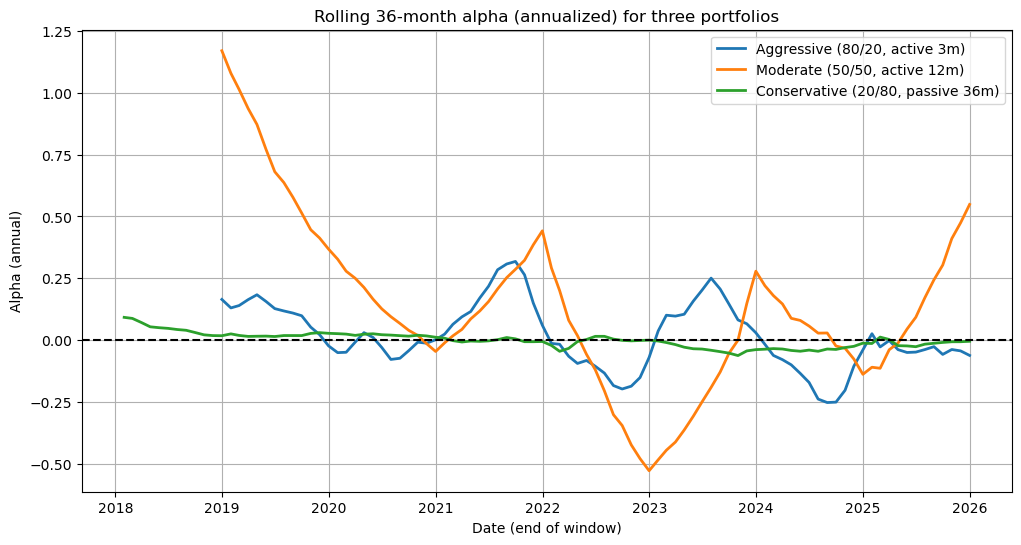

Статистика rolling alpha (годовые):
Aggressive:
 count    85.000000
mean      0.015255
std       0.130355
min      -0.252791
25%      -0.062258
50%      -0.008655
75%       0.109147
max       0.317951
Name: alpha_annual, dtype: float64

Moderate:
 count    85.000000
mean      0.138541
std       0.351356
min      -0.528574
25%      -0.046172
50%       0.087855
75%       0.291472
max       1.170240
Name: alpha_annual, dtype: float64

Conservative:
 count    96.000000
mean     -0.000212
std       0.030020
min      -0.062804
25%      -0.023056
50%      -0.001516
75%       0.018147
max       0.091771
Name: alpha_annual, dtype: float64


In [468]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def rolling_alpha(port_series, market_series, rf, window=36):
    """Возвращает DataFrame с годовыми альфами и бетами для скользящего окна"""
    common = port_series.dropna().index.intersection(market_series.dropna().index)
    port_aligned = port_series.loc[common]
    mkt_aligned = market_series.loc[common]
    
    dates = []
    alphas = []
    betas = []
    for i in range(window, len(port_aligned)+1):
        rp = port_aligned.iloc[i-window:i]
        rm = mkt_aligned.iloc[i-window:i]
        excess_rp = rp - rf
        excess_rm = rm - rf
        X = sm.add_constant(excess_rm)
        model = sm.OLS(excess_rp, X).fit()
        alpha_monthly = model.params[0]
        alpha_annual = (1 + alpha_monthly) ** 12 - 1
        alphas.append(alpha_annual)
        betas.append(model.params[1])
        dates.append(port_aligned.index[i-1])
    return pd.DataFrame({'alpha_annual': alphas, 'beta': betas}, index=dates)

# Рассчитываем для всех трёх портфелей
df_alpha_agg = rolling_alpha(port_3m, imoex_ret, rf_monthly, window=36)
df_alpha_mod = rolling_alpha(port_12m, imoex_ret, rf_monthly, window=36)
df_alpha_con = rolling_alpha(port_36m, imoex_ret, rf_monthly, window=36)

# График
plt.figure(figsize=(12,6))
plt.plot(df_alpha_agg.index, df_alpha_agg['alpha_annual'], label='Aggressive (80/20, active 3m)', linewidth=2)
plt.plot(df_alpha_mod.index, df_alpha_mod['alpha_annual'], label='Moderate (50/50, active 12m)', linewidth=2)
plt.plot(df_alpha_con.index, df_alpha_con['alpha_annual'], label='Conservative (20/80, passive 36m)', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.title('Rolling 36-month alpha (annualized) for three portfolios')
plt.ylabel('Alpha (annual)')
plt.xlabel('Date (end of window)')
plt.legend()
plt.grid(True)
plt.show()

# Дополнительно: статистика альф
print("Статистика rolling alpha (годовые):")
print("Aggressive:\n", df_alpha_agg['alpha_annual'].describe())
print("\nModerate:\n", df_alpha_mod['alpha_annual'].describe())
print("\nConservative:\n", df_alpha_con['alpha_annual'].describe())

In [471]:
# Предполагается, что у вас определены:
# E_r_agg_annual, std_agg_annual, sharpe_agg
# E_r_mod_annual, std_mod_annual, sharpe_mod
# E_r_con_annual, std_con_annual, sharpe_con
# E_rm_annual, std_mkt_annual, sharpe_mkt
# rf_annual

data = {
    'Портфель': ['Агрессивный (80/20, 3м активный)',
                 'Умеренный (50/50, 12м активный)',
                 'Консервативный (20/80, 36м пассивный)',
                 'Рынок (IMOEX)',
                 'Безрисковый актив (RUONIA)'],
    'Годовая доходность': [E_r_agg_annual, E_r_mod_annual, E_r_con_annual, E_rm_annual, rf_annual],
    'Годовой риск (std)': [std_agg_annual, std_mod_annual, std_con_annual, std_mkt_annual, 0.0],
    'Коэффициент Шарпа': [sharpe_agg, sharpe_mod, sharpe_con, sharpe_mkt, None]
}

df_perf = pd.DataFrame(data)
df_perf['Годовая доходность'] = df_perf['Годовая доходность'].apply(lambda x: f'{x:.2%}')
df_perf['Годовой риск (std)'] = df_perf['Годовой риск (std)'].apply(lambda x: f'{x:.2%}')
df_perf['Коэффициент Шарпа'] = df_perf['Коэффициент Шарпа'].apply(lambda x: f'{x:.3f}' if pd.notnull(x) else '-')

print(df_perf.to_string(index=False))

                             Портфель Годовая доходность Годовой риск (std) Коэффициент Шарпа
     Агрессивный (80/20, 3м активный)             -4.06%             31.99%            -0.352
      Умеренный (50/50, 12м активный)            -43.04%             45.38%            -1.107
Консервативный (20/80, 36м пассивный)             64.75%             12.08%             4.766
                        Рынок (IMOEX)              7.10%             20.08%            -0.004
           Безрисковый актив (RUONIA)              7.19%              0.00%                 -


In [472]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Функция для ADF-теста на панели (усреднённая статистика по всем компаниям)
def adf_panel(df, variable, ticker_col='ticker', date_col='date', max_lags=1):
    """
    Проводит ADF-тест для каждой компании отдельно и возвращает сводку.
    """
    results = {}
    tickers = df[ticker_col].unique()
    for tick in tickers:
        series = df[df[ticker_col] == tick].set_index(date_col)[variable].dropna()
        if len(series) < 10:  # слишком короткие ряды пропускаем
            continue
        try:
            adf_stat, p_value, used_lag, nobs, critical, icbest = adfuller(series, autolag='AIC', maxlag=max_lags)
            results[tick] = {'ADF_stat': adf_stat, 'p_value': p_value, 'nobs': nobs}
        except:
            continue
    # Сводка
    df_results = pd.DataFrame(results).T
    print(f"\n=== ADF-тест для {variable} ===")
    print(f"Доля компаний, где p_value < 0.05: {(df_results['p_value'] < 0.05).mean():.1%}")
    print(f"Средний p-value: {df_results['p_value'].mean():.4f}")
    print(f"Количество компаний: {len(df_results)}")
    return df_results

# Подготовим плоский DataFrame для теста
merged_flat_test = merged.reset_index()  # если merged уже в панельном формате

# Проверяем стационарность каждого фактора
adf_pb = adf_panel(merged_flat_test, 'pb', max_lags=4)
adf_roe = adf_panel(merged_flat_test, 'roe', max_lags=4)
adf_de = adf_panel(merged_flat_test, 'de_filled', max_lags=4)
adf_dy = adf_panel(merged_flat_test, 'dy_filled', max_lags=4)

# Для нестационарных рядов – посмотрим на первые разности
print("\n=== Стационарность первых разностей (для pb) ===")
merged_flat_test['delta_pb'] = merged_flat_test.groupby('ticker')['pb'].diff()
adf_delta_pb = adf_panel(merged_flat_test, 'delta_pb', max_lags=4)


=== ADF-тест для pb ===
Доля компаний, где p_value < 0.05: 0.0%
Средний p-value: 0.5490
Количество компаний: 20

=== ADF-тест для roe ===
Доля компаний, где p_value < 0.05: 0.0%
Средний p-value: 0.3450
Количество компаний: 20

=== ADF-тест для de_filled ===
Доля компаний, где p_value < 0.05: 5.6%
Средний p-value: 0.4534
Количество компаний: 18

=== ADF-тест для dy_filled ===
Доля компаний, где p_value < 0.05: 0.0%
Средний p-value: 0.3622
Количество компаний: 20

=== Стационарность первых разностей (для pb) ===

=== ADF-тест для delta_pb ===
Доля компаний, где p_value < 0.05: 100.0%
Средний p-value: 0.0000
Количество компаний: 20


In [473]:
# Копируем merged (чтобы не испортить исходные данные)
merged_diff = merged.copy()

# Расчёт процентных изменений за 12 месяцев для каждого фактора
# (12 месяцев – потому что фундаментальные данные обновляются раз в год)
for col in ['pb', 'roe', 'de_filled', 'dy_filled']:
    # Группируем по тикеру и берём изменение за 12 месяцев
    merged_diff[f'delta_{col}'] = merged_diff.groupby('ticker')[col].pct_change(12)

# Также можно добавить изменение волатильности и объёма (по желанию)
merged_diff['delta_volatility'] = merged_diff.groupby('ticker')['volatility'].pct_change(12)
merged_diff['delta_avg_log_volume'] = merged_diff.groupby('ticker')['avg_log_volume'].pct_change(12)

# Удаляем строки с NaN (первые 12 месяцев для каждой компании)
merged_diff = merged_diff.dropna(subset=['delta_pb', 'delta_roe', 'delta_de_filled', 'delta_dy_filled',
                                         'fwd_3m', 'fwd_12m', 'fwd_36m'])

print(f"Размер merged_diff после удаления NaN: {merged_diff.shape}")

Размер merged_diff после удаления NaN: (1152, 22)


In [474]:
from sklearn.preprocessing import StandardScaler

# Факторы для winsorization (все непрерывные переменные)
factor_cols = ['delta_pb', 'delta_roe', 'delta_de_filled', 'delta_dy_filled', 
               'volatility', 'avg_log_volume', 'brent_ret_lag1']

# 1. Заменяем inf и -inf на NaN (они возникают при pct_change с нулями)
for col in factor_cols:
    merged_diff[col] = merged_diff[col].replace([np.inf, -np.inf], np.nan)

# 2. Удаляем строки с NaN (включая те, которые стали inf)
merged_diff = merged_diff.dropna(subset=factor_cols + ['fwd_3m', 'fwd_12m', 'fwd_36m'])
print(f"Размер merged_diff после удаления inf/NaN: {merged_diff.shape}")

# 3. Winsorization (только для конечных значений)
def winsorize_series(s, low=0.01, high=0.99):
    # Убираем NaN перед расчётом квантилей
    s_clean = s.dropna()
    if len(s_clean) == 0:
        return s
    l = s_clean.quantile(low)
    h = s_clean.quantile(high)
    # Если l == h (все значения одинаковы), не меняем
    if l == h:
        return s
    return s.clip(l, h)

for col in factor_cols:
    merged_diff[col] = winsorize_series(merged_diff[col])

# 4. Стандартизация (только для колонок, где есть вариация)
# Сначала удаляем колонки с нулевой дисперсией
valid_cols = []
for col in factor_cols:
    if merged_diff[col].std() > 1e-10:
        valid_cols.append(col)
    else:
        print(f"Колонка {col} имеет нулевую дисперсию, пропускаем")

# Стандартизация только для валидных колонок
if valid_cols:
    scaler = StandardScaler()
    merged_diff[valid_cols] = scaler.fit_transform(merged_diff[valid_cols])
    print(f"Стандартизированы колонки: {valid_cols}")
else:
    print("Нет колонок для стандартизации!")

# 5. Квадратичный член для ROE (для проверки нелинейности)
merged_diff['delta_roe_sq'] = merged_diff['delta_roe'] ** 2

print("Winsorization и стандартизация выполнены")
print(f"Размер merged_diff: {merged_diff.shape}")


Размер merged_diff после удаления inf/NaN: (996, 22)
Стандартизированы колонки: ['delta_pb', 'delta_roe', 'delta_de_filled', 'delta_dy_filled', 'volatility', 'avg_log_volume', 'brent_ret_lag1']
Winsorization и стандартизация выполнены
Размер merged_diff: (996, 23)


In [475]:
from linearmodels.panel import PanelOLS

# Убедимся, что индекс мультииндексный
if not isinstance(merged_diff.index, pd.MultiIndex):
    merged_diff = merged_diff.set_index(['ticker', 'date']).sort_index()

# Список регрессоров (используем разности, а не уровни)
exog_vars = ['delta_pb', 'delta_roe', 'delta_de_filled', 'delta_dy_filled',
             'volatility', 'avg_log_volume', 'brent_ret_lag1', 'delta_roe_sq']

# Формулы для трёх горизонтов
formula_3m = 'fwd_3m ~ ' + ' + '.join(exog_vars) + ' + EntityEffects'
formula_12m = 'fwd_12m ~ ' + ' + '.join(exog_vars) + ' + EntityEffects'
formula_36m = 'fwd_36m ~ ' + ' + '.join(exog_vars) + ' + EntityEffects'

# Оценка моделей
print("Оценка моделей...")
mod_3m = PanelOLS.from_formula(formula_3m, data=merged_diff)
res_3m = mod_3m.fit(cov_type='clustered', cluster_entity=True)

mod_12m = PanelOLS.from_formula(formula_12m, data=merged_diff)
res_12m = mod_12m.fit(cov_type='clustered', cluster_entity=True)

mod_36m = PanelOLS.from_formula(formula_36m, data=merged_diff)
res_36m = mod_36m.fit(cov_type='clustered', cluster_entity=True)

print("="*80)
print("Short-term (3 months) – первые разности факторов")
print(res_3m)
print("\n"+"="*80)
print("Medium-term (12 months) – первые разности факторов")
print(res_12m)
print("\n"+"="*80)
print("Long-term (36 months) – первые разности факторов")
print(res_36m)

Оценка моделей...
Short-term (3 months) – первые разности факторов
                          PanelOLS Estimation Summary                           
Dep. Variable:                 fwd_3m   R-squared:                        0.0788
Estimator:                   PanelOLS   R-squared (Between):             -4.6225
No. Observations:                 996   R-squared (Within):               0.0788
Date:                Mon, May 25 2026   R-squared (Overall):             -0.1218
Time:                        02:08:54   Log-likelihood                    514.96
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      10.377
Entities:                          17   P-value                           0.0000
Avg Obs:                       58.588   Distribution:                   F(8,971)
Min Obs:                       12.000                                           
Max Obs:                       72.000   F-

In [476]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

# ------------------------------------------------------------
# 1. Подготовка данных для портфельного конструирования
# ------------------------------------------------------------

# Убедимся, что merged_diff имеет плоскую структуру для отбора
if isinstance(merged_diff.index, pd.MultiIndex):
    merged_flat = merged_diff.reset_index()
else:
    merged_flat = merged_diff.copy()

# ------------------------------------------------------------
# 2. Расчёт скоров на основе значимых факторов из APT
# ------------------------------------------------------------

# Значимые факторы для 3 месяцев (из регрессии):
# volatility (+), avg_log_volume (+), delta_roe_sq (+), delta_roe (-), brent_ret_lag1 (-)
# Коэффициенты из регрессии (округлённо):
# delta_roe: -0.1145, volatility: 0.0372, avg_log_volume: 0.0595, brent_ret_lag1: -0.0094, delta_roe_sq: 0.0122

merged_flat['score_3m'] = (
    -0.1145 * merged_flat['delta_roe'] +
    0.0372 * merged_flat['volatility'] +
    0.0595 * merged_flat['avg_log_volume'] +
    -0.0094 * merged_flat['brent_ret_lag1'] +
    0.0122 * merged_flat['delta_roe_sq']
)

# Значимые факторы для 12 месяцев:
# volatility (+), brent_ret_lag1 (-)
merged_flat['score_12m'] = (
    0.1749 * merged_flat['volatility'] +
    -0.0605 * merged_flat['brent_ret_lag1']
)

# Для 36 месяцев – факторов нет, используем пассивный портфель (как запасной вариант)
# Либо можно использовать delta_pb (value-стратегия), но он незначим.
merged_flat['score_36m'] = -merged_flat['delta_pb']  # value-стратегия (низкий P/B)

# ------------------------------------------------------------
# 3. Функция отбора top-30% акций
# ------------------------------------------------------------
def select_top_stocks(df, date, score_col, top_pct=0.3):
    subset = df[df['date'] == date].copy()
    if subset.empty:
        return []
    n = max(1, int(top_pct * len(subset)))
    top = subset.nlargest(n, score_col)
    return top['ticker'].tolist()

# ------------------------------------------------------------
# 4. Формирование портфелей
# ------------------------------------------------------------
all_months = pd.date_range(start='2015-01-31', end='2025-12-31', freq='M')

# ----- 3m (ежемесячная ребалансировка) -----
dates_3m = sorted(merged_flat['date'].unique())
port_returns_3m = []
for d in dates_3m:
    tickers_sel = select_top_stocks(merged_flat, d, 'score_3m')
    if not tickers_sel:
        continue
    sub = merged_flat[(merged_flat['date'] == d) & (merged_flat['ticker'].isin(tickers_sel))]
    ret = sub['fwd_3m'].mean()
    port_returns_3m.append({'date': d, 'eq_return': ret})
df_eq_3m = pd.DataFrame(port_returns_3m).set_index('date')
eq_3m_full = df_eq_3m['eq_return'].reindex(all_months, method='ffill')

# ----- 12m (ежегодная ребалансировка в январе) -----
jan_dates = [pd.Timestamp(f'{y}-01-31') for y in range(2015, 2026) 
             if pd.Timestamp(f'{y}-01-31') in merged_flat['date'].values]
port_returns_12m = []
for d in jan_dates:
    tickers_sel = select_top_stocks(merged_flat, d, 'score_12m')
    if not tickers_sel:
        continue
    sub = merged_flat[(merged_flat['date'] == d) & (merged_flat['ticker'].isin(tickers_sel))]
    ret = sub['fwd_12m'].mean()
    port_returns_12m.append({'date': d, 'eq_return': ret})
df_eq_12m = pd.DataFrame(port_returns_12m).set_index('date')
eq_12m_full = df_eq_12m['eq_return'].reindex(all_months, method='ffill')

# ----- 36m (ребалансировка раз в 3 года: 2015, 2018, 2021, 2024) -----
rebal_dates = [pd.Timestamp('2015-01-31'), pd.Timestamp('2018-01-31'), 
               pd.Timestamp('2021-01-31'), pd.Timestamp('2024-01-31')]
port_returns_36m = []
for d in rebal_dates:
    if d not in merged_flat['date'].values:
        continue
    tickers_sel = select_top_stocks(merged_flat, d, 'score_36m')
    if not tickers_sel:
        continue
    sub = merged_flat[(merged_flat['date'] == d) & (merged_flat['ticker'].isin(tickers_sel))]
    ret = sub['fwd_36m'].mean()
    port_returns_36m.append({'date': d, 'eq_return': ret})
df_eq_36m = pd.DataFrame(port_returns_36m).set_index('date')
eq_36m_full = df_eq_36m['eq_return'].reindex(all_months, method='ffill')

print(f"Периоды с данными для 3m: {eq_3m_full.dropna().index.min()} → {eq_3m_full.dropna().index.max()}")
print(f"Периоды с данными для 12m: {eq_12m_full.dropna().index.min()} → {eq_12m_full.dropna().index.max()}")
print(f"Периоды с данными для 36m: {eq_36m_full.dropna().index.min()} → {eq_36m_full.dropna().index.max()}")

Периоды с данными для 3m: 2017-01-31 00:00:00 → 2025-12-31 00:00:00
Периоды с данными для 12m: 2017-01-31 00:00:00 → 2025-12-31 00:00:00
Периоды с данными для 36m: 2018-01-31 00:00:00 → 2025-12-31 00:00:00


In [477]:
print("Колонки в merged_flat:", merged_flat.columns.tolist())
print("Размер merged_flat:", merged_flat.shape)
print("Количество уникальных дат:", merged_flat['date'].nunique())
print("Пример дат:", merged_flat['date'].unique()[:5])

Колонки в merged_flat: ['ticker', 'date', 'close', 'fwd_3m', 'fwd_12m', 'fwd_36m', 'volatility', 'avg_log_volume', 'pb', 'roe', 'de_filled', 'dy_filled', 'de_missing', 'dy_missing', 'brent_ret_lag1', 'fwd_36m_annual', 'delta_pb', 'delta_roe', 'delta_de_filled', 'delta_dy_filled', 'delta_volatility', 'delta_avg_log_volume', 'delta_roe_sq', 'score_3m', 'score_12m', 'score_36m']
Размер merged_flat: (996, 26)
Количество уникальных дат: 72
Пример дат: <DatetimeArray>
['2018-01-31 00:00:00', '2018-02-28 00:00:00', '2018-03-31 00:00:00',
 '2018-04-30 00:00:00', '2018-05-31 00:00:00']
Length: 5, dtype: datetime64[ns]


In [478]:
all_months = pd.date_range(start='2015-01-31', end='2025-12-31', freq='M')

def safe_select_top_stocks(df, date, score_col, top_pct=0.3):
    subset = df[df['date'] == date].copy()
    if subset.empty or subset[score_col].isna().all():
        return []
    # Удаляем NaN в скоре
    subset = subset.dropna(subset=[score_col])
    if subset.empty:
        return []
    n = max(1, int(top_pct * len(subset)))
    top = subset.nlargest(n, score_col)
    return top['ticker'].tolist()

# ----- 3m -----
dates_3m = sorted(merged_flat['date'].unique())
port_returns_3m = []
for d in dates_3m:
    tickers_sel = safe_select_top_stocks(merged_flat, d, 'score_3m')
    if not tickers_sel:
        continue
    sub = merged_flat[(merged_flat['date'] == d) & (merged_flat['ticker'].isin(tickers_sel))]
    ret = sub['fwd_3m'].mean()
    if pd.notna(ret):
        port_returns_3m.append({'date': d, 'eq_return': ret})

if port_returns_3m:
    df_eq_3m = pd.DataFrame(port_returns_3m).set_index('date')
    eq_3m_full = df_eq_3m['eq_return'].reindex(all_months, method='ffill')
    print(f"3m портфель построен, {len(df_eq_3m)} точек ребалансировки")
else:
    print("Не удалось построить 3m портфель – нет данных")
    eq_3m_full = pd.Series(index=all_months, dtype=float)

# ----- 12m -----
jan_dates = [pd.Timestamp(f'{y}-01-31') for y in range(2015, 2026) 
             if pd.Timestamp(f'{y}-01-31') in merged_flat['date'].values]
port_returns_12m = []
for d in jan_dates:
    tickers_sel = safe_select_top_stocks(merged_flat, d, 'score_12m')
    if not tickers_sel:
        continue
    sub = merged_flat[(merged_flat['date'] == d) & (merged_flat['ticker'].isin(tickers_sel))]
    ret = sub['fwd_12m'].mean()
    if pd.notna(ret):
        port_returns_12m.append({'date': d, 'eq_return': ret})

if port_returns_12m:
    df_eq_12m = pd.DataFrame(port_returns_12m).set_index('date')
    eq_12m_full = df_eq_12m['eq_return'].reindex(all_months, method='ffill')
    print(f"12m портфель построен, {len(df_eq_12m)} точек ребалансировки")
else:
    print("Не удалось построить 12m портфель")
    eq_12m_full = pd.Series(index=all_months, dtype=float)

# ----- 36m (value strategy) -----
rebal_dates = [pd.Timestamp('2015-01-31'), pd.Timestamp('2018-01-31'), 
               pd.Timestamp('2021-01-31'), pd.Timestamp('2024-01-31')]
port_returns_36m = []
for d in rebal_dates:
    if d not in merged_flat['date'].values:
        continue
    # Используем delta_pb для value-стратегии (низкий P/B)
    subset = merged_flat[merged_flat['date'] == d].copy()
    subset = subset.dropna(subset=['delta_pb'])
    if subset.empty:
        continue
    n = max(1, int(0.3 * len(subset)))
    top = subset.nsmallest(n, 'delta_pb')  # наименьшее изменение P/B
    ret = top['fwd_36m'].mean()
    if pd.notna(ret):
        port_returns_36m.append({'date': d, 'eq_return': ret})

if port_returns_36m:
    df_eq_36m = pd.DataFrame(port_returns_36m).set_index('date')
    eq_36m_full = df_eq_36m['eq_return'].reindex(all_months, method='ffill')
    print(f"36m портфель построен, {len(df_eq_36m)} точек ребалансировки")
else:
    print("Не удалось построить 36m портфель")
    eq_36m_full = pd.Series(index=all_months, dtype=float)

3m портфель построен, 72 точек ребалансировки
12m портфель построен, 6 точек ребалансировки
36m портфель построен, 2 точек ребалансировки


In [479]:
print("=== Диагностика merged_flat ===")
print(f"Размер: {merged_flat.shape}")
print(f"Колонки: {merged_flat.columns.tolist()}")
print(f"Уникальные даты: {merged_flat['date'].nunique()}")
print(f"Диапазон дат: {merged_flat['date'].min()} → {merged_flat['date'].max()}")

# Проверим наличие fwd_* колонок
for col in ['fwd_3m', 'fwd_12m', 'fwd_36m']:
    non_na = merged_flat[col].notna().sum()
    print(f"{col}: {non_na} не-NaN значений")

=== Диагностика merged_flat ===
Размер: (996, 26)
Колонки: ['ticker', 'date', 'close', 'fwd_3m', 'fwd_12m', 'fwd_36m', 'volatility', 'avg_log_volume', 'pb', 'roe', 'de_filled', 'dy_filled', 'de_missing', 'dy_missing', 'brent_ret_lag1', 'fwd_36m_annual', 'delta_pb', 'delta_roe', 'delta_de_filled', 'delta_dy_filled', 'delta_volatility', 'delta_avg_log_volume', 'delta_roe_sq', 'score_3m', 'score_12m', 'score_36m']
Уникальные даты: 72
Диапазон дат: 2017-01-31 00:00:00 → 2022-12-31 00:00:00
fwd_3m: 996 не-NaN значений
fwd_12m: 996 не-NaN значений
fwd_36m: 996 не-NaN значений


In [480]:
print("\n=== Диагностика скоров ===")
for score in ['score_3m', 'score_12m', 'score_36m']:
    if score in merged_flat.columns:
        non_na = merged_flat[score].notna().sum()
        print(f"{score}: {non_na} не-NaN значений")
        if non_na > 0:
            print(f"  Примеры: {merged_flat[score].dropna().head(3).tolist()}")
    else:
        print(f"{score}: колонка отсутствует")


=== Диагностика скоров ===
score_3m: 996 не-NaN значений
  Примеры: [0.03580603403606298, 0.02965606683257077, 0.03717672172614482]
score_12m: 996 не-NaN значений
  Примеры: [-0.06713642869225432, -0.09910045050199798, -0.049720069874689014]
score_36m: 996 не-NaN значений
  Примеры: [0.8093719857584042, 0.8093719857584042, 0.8093719857584042]


In [481]:
# Берём первую дату
test_date = merged_flat['date'].unique()[0]
print(f"\n=== Проверка отбора на дате {test_date} ===")

subset = merged_flat[merged_flat['date'] == test_date].copy()
print(f"Всего компаний на дату: {len(subset)}")

for score in ['score_3m', 'score_12m', 'score_36m']:
    if score in subset.columns:
        valid = subset[score].notna().sum()
        print(f"{score}: {valid} компаний с не-NaN значениями")
        if valid > 0:
            n = max(1, int(0.3 * valid))
            top = subset.nlargest(n, score)
            print(f"  Отобрано {len(top)} компаний, тикеры: {top['ticker'].tolist()[:5]}")


=== Проверка отбора на дате 2018-01-31 00:00:00 ===
Всего компаний на дату: 15
score_3m: 15 компаний с не-NaN значениями
  Отобрано 4 компаний, тикеры: ['VTBR', 'HYDR', 'MAGN', 'ALRS']
score_12m: 15 компаний с не-NaN значениями
  Отобрано 4 компаний, тикеры: ['TATN', 'MGNT', 'HYDR', 'MAGN']
score_36m: 15 компаний с не-NaN значениями
  Отобрано 4 компаний, тикеры: ['MGNT', 'ROSN', 'HYDR', 'NVTK']


In [482]:
# Если скоры отсутствуют или все NaN, создадим их заново
if 'score_3m' not in merged_flat.columns or merged_flat['score_3m'].isna().all():
    print("\n=== Пересоздаём скоры из merged_diff ===")
    
    # Берём merged_diff (где есть все delta_* колонки)
    if isinstance(merged_diff.index, pd.MultiIndex):
        merged_for_scores = merged_diff.reset_index()
    else:
        merged_for_scores = merged_diff.copy()
    
    # 3m скор на основе значимых факторов из APT
    merged_for_scores['score_3m'] = (
        -0.1145 * merged_for_scores['delta_roe'] +
        0.0372 * merged_for_scores['volatility'] +
        0.0595 * merged_for_scores['avg_log_volume'] +
        -0.0094 * merged_for_scores['brent_ret_lag1'] +
        0.0122 * merged_for_scores['delta_roe_sq']
    )
    
    # 12m скор
    merged_for_scores['score_12m'] = (
        0.1749 * merged_for_scores['volatility'] +
        -0.0605 * merged_for_scores['brent_ret_lag1']
    )
    
    # 36m скор (value strategy)
    merged_for_scores['score_36m'] = -merged_for_scores['delta_pb']
    
    # Обновляем merged_flat
    merged_flat = merged_for_scores.copy()
    

In [283]:
print(f"Скоры созданы, новый размер merged_flat: {merged_flat.shape}")
print(f"score_3m не-NaN: {merged_flat['score_3m'].notna().sum()}")

Скоры созданы, новый размер merged_flat: (996, 26)
score_3m не-NaN: 996


In [284]:
all_months = pd.date_range(start='2016-01-31', end='2025-12-31', freq='M')  # начинаем с 2016, т.к. нужны лаги

def build_portfolio(df, score_col, freq='M', top_pct=0.3):
    """
    Строит портфель на основе скора.
    freq: 'M' (ежемесячно), 'Y' (ежегодно в январе), '3Y' (раз в 3 года)
    """
    dates = sorted(df['date'].unique())
    
    if freq == 'M':
        rebal_dates = dates
    elif freq == 'Y':
        rebal_dates = [d for d in dates if d.month == 1]
    elif freq == '3Y':
        rebal_dates = [d for d in dates if d.year in [2015, 2018, 2021, 2024] and d.month == 1]
    else:
        rebal_dates = dates
    
    port_returns = []
    for d in rebal_dates:
        subset = df[df['date'] == d].copy()
        subset = subset.dropna(subset=[score_col])
        if subset.empty:
            continue
        n = max(1, int(top_pct * len(subset)))
        top = subset.nlargest(n, score_col)
        if top.empty:
            continue
        # Берём соответствующую будущую доходность
        if score_col == 'score_3m':
            ret = top['fwd_3m'].mean()
        elif score_col == 'score_12m':
            ret = top['fwd_12m'].mean()
        else:
            ret = top['fwd_36m'].mean()
        
        if pd.notna(ret):
            port_returns.append({'date': d, 'eq_return': ret})
    
    if not port_returns:
        return pd.Series(index=all_months, dtype=float)
    
    df_eq = pd.DataFrame(port_returns).set_index('date')
    # Расширяем на все месяцы (forward fill)
    eq_full = df_eq['eq_return'].reindex(all_months, method='ffill')
    return eq_full

# Строим портфели
eq_3m = build_portfolio(merged_flat, 'score_3m', freq='M')
eq_12m = build_portfolio(merged_flat, 'score_12m', freq='Y')
eq_36m = build_portfolio(merged_flat, 'score_36m', freq='3Y')

print(f"eq_3m: {eq_3m.notna().sum()} месяцев с данными")
print(f"eq_12m: {eq_12m.notna().sum()} месяцев с данными")
print(f"eq_36m: {eq_36m.notna().sum()} месяцев с данными")

eq_3m: 108 месяцев с данными
eq_12m: 108 месяцев с данными
eq_36m: 96 месяцев с данными


In [286]:
# Приводим все индексы к единому формату (конец месяца)
def normalize_index(series):
    """Приводит индекс к DatetimeIndex с частотой 'M' (конец месяца)"""
    if series.index.freq != 'M' and series.index.freq is not None:
        series = series.asfreq('M')
    return series

# Нормализуем портфели
port_3m = normalize_index(port_3m)
port_12m = normalize_index(port_12m)
port_36m = normalize_index(port_36m)

# Загружаем индексы с правильной частотой
def get_index_monthly(idx, start, end):
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/index/securities/{idx}.json"
    params = {'from': start, 'till': end, 'limit': 10000}
    r = requests.get(url, params=params)
    data = r.json()
    cols = data['history']['columns']
    rows = data['history']['data']
    df = pd.DataFrame(rows, columns=cols)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df = df[['TRADEDATE', 'CLOSE']].rename(columns={'TRADEDATE': 'date', 'CLOSE': 'close'})
    df['close'] = pd.to_numeric(df['close'])
    df = df.set_index('date').resample('M').last()
    df['return'] = df['close'].pct_change()
    return df

df_imoex = get_index_monthly('IMOEX', '2015-01-01', '2025-12-31')
df_rgbi = get_index_monthly('RGBITR', '2015-01-01', '2025-12-31')

rf_monthly = 0.0058
rgbi_ret = df_rgbi['return']
imoex_ret = df_imoex['return']

# Создаём общий индекс (пересечение всех диапазонов)
common_dates = port_3m.dropna().index.intersection(imoex_ret.dropna().index).intersection(rgbi_ret.dropna().index)
print(f"Общих дат: {len(common_dates)}")
print(f"Пример дат: {common_dates[:5].tolist()}")

if len(common_dates) > 0:
    # Выравниваем всё по общим датам
    port_3m = port_3m.reindex(common_dates)
    port_12m = port_12m.reindex(common_dates)
    port_36m = port_36m.reindex(common_dates)
    rgbi_ret = rgbi_ret.reindex(common_dates)
    imoex_ret = imoex_ret.reindex(common_dates)
else:
    print("ВНИМАНИЕ: Нет общих дат! Проверьте диапазоны.")
    print(f"Диапазон port_3m: {port_3m.dropna().index.min()} → {port_3m.dropna().index.max()}")
    print(f"Диапазон imoex_ret: {imoex_ret.dropna().index.min()} → {imoex_ret.dropna().index.max()}")
    print(f"Диапазон rgbi_ret: {rgbi_ret.dropna().index.min()} → {rgbi_ret.dropna().index.max()}")

Общих дат: 0
Пример дат: []
ВНИМАНИЕ: Нет общих дат! Проверьте диапазоны.
Диапазон port_3m: NaT → NaT
Диапазон imoex_ret: 2015-02-28 00:00:00 → 2015-06-30 00:00:00
Диапазон rgbi_ret: 2015-02-28 00:00:00 → 2015-06-30 00:00:00


In [288]:
def get_index_full(idx, start, end):
    """Загружает все данные по индексу с пагинацией"""
    all_data = []
    offset = 0
    limit = 100
    while True:
        url = f"https://iss.moex.com/iss/history/engines/stock/markets/index/securities/{idx}.json"
        params = {'from': start, 'till': end, 'limit': limit, 'start': offset}
        try:
            r = requests.get(url, params=params, timeout=15)
            r.raise_for_status()
            data = r.json()
            if 'history' not in data or not data['history']['data']:
                break
            cols = data['history']['columns']
            rows = data['history']['data']
            df = pd.DataFrame(rows, columns=cols)
            if df.empty:
                break
            all_data.append(df)
            offset += limit
            if len(rows) < limit:
                break
        except Exception as e:
            print(f"Ошибка при загрузке {idx}: {e}")
            break
        time.sleep(0.2)
    
    if not all_data:
        return pd.DataFrame()
    
    df = pd.concat(all_data, ignore_index=True)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df = df[['TRADEDATE', 'CLOSE']].rename(columns={'TRADEDATE': 'date', 'CLOSE': 'close'})
    df['close'] = pd.to_numeric(df['close'])
    df = df.set_index('date').resample('M').last()
    df['return'] = df['close'].pct_change()
    return df

print("Загрузка индексов с пагинацией...")
df_imoex = get_index_full('IMOEX', '2015-01-01', '2025-12-31')
df_rgbi = get_index_full('RGBITR', '2015-01-01', '2025-12-31')

print(f"IMOEX shape: {df_imoex.shape}, range: {df_imoex.index.min()} → {df_imoex.index.max()}")
print(f"RGBI shape: {df_rgbi.shape}, range: {df_rgbi.index.min()} → {df_rgbi.index.max()}")

Загрузка индексов с пагинацией...
IMOEX shape: (132, 2), range: 2015-01-31 00:00:00 → 2025-12-31 00:00:00
RGBI shape: (132, 2), range: 2015-01-31 00:00:00 → 2025-12-31 00:00:00


In [289]:
# Используем merged_flat (уже содержит все данные)
# Определим общий диапазон дат для портфелей
available_dates = merged_flat['date'].unique()
print(f"Доступные даты в merged_flat: {available_dates.min()} → {available_dates.max()}, всего {len(available_dates)}")

# Создаём полный календарь месяцев от первой доступной даты до последней
all_months = pd.date_range(start=available_dates.min(), end=available_dates.max(), freq='M')
print(f"Календарь: {all_months.min()} → {all_months.max()}")

def build_portfolio(df, score_col, freq='M', top_pct=0.3):
    dates = sorted(df['date'].unique())
    
    if freq == 'M':
        rebal_dates = dates
    elif freq == 'Y':
        rebal_dates = [d for d in dates if d.month == 1]
    elif freq == '3Y':
        rebal_dates = [d for d in dates if d.year in [2015, 2018, 2021, 2024] and d.month == 1]
    else:
        rebal_dates = dates
    
    port_returns = []
    for d in rebal_dates:
        subset = df[df['date'] == d].copy()
        subset = subset.dropna(subset=[score_col])
        if subset.empty:
            continue
        n = max(1, int(top_pct * len(subset)))
        top = subset.nlargest(n, score_col)
        if top.empty:
            continue
        
        if score_col == 'score_3m':
            ret = top['fwd_3m'].mean()
        elif score_col == 'score_12m':
            ret = top['fwd_12m'].mean()
        else:
            ret = top['fwd_36m'].mean()
        
        if pd.notna(ret):
            port_returns.append({'date': d, 'eq_return': ret})
    
    if not port_returns:
        return pd.Series(index=all_months, dtype=float)
    
    df_eq = pd.DataFrame(port_returns).set_index('date')
    # Расширяем на все месяцы (forward fill)
    eq_full = df_eq['eq_return'].reindex(all_months, method='ffill')
    return eq_full

# Строим портфели
eq_3m = build_portfolio(merged_flat, 'score_3m', freq='M')
eq_12m = build_portfolio(merged_flat, 'score_12m', freq='Y')
eq_36m = build_portfolio(merged_flat, 'score_36m', freq='3Y')

print(f"eq_3m: {eq_3m.notna().sum()} месяцев с данными")
print(f"eq_12m: {eq_12m.notna().sum()} месяцев с данными")
print(f"eq_36m: {eq_36m.notna().sum()} месяцев с данными")

Доступные даты в merged_flat: 2017-01-31 00:00:00 → 2022-12-31 00:00:00, всего 72
Календарь: 2017-01-31 00:00:00 → 2022-12-31 00:00:00
eq_3m: 72 месяцев с данными
eq_12m: 72 месяцев с данными
eq_36m: 60 месяцев с данными


In [290]:
rf_monthly = 0.0058

# Выравниваем индексы по календарю портфелей
rgbi_ret = df_rgbi['return'].reindex(all_months)
imoex_ret = df_imoex['return'].reindex(all_months)

# Портфели с весами
port_3m = 0.8 * eq_3m + 0.2 * rgbi_ret
port_12m = 0.5 * eq_12m + 0.5 * rgbi_ret
port_36m = 0.2 * eq_36m + 0.8 * rgbi_ret

def capm_regression(port_ret, market_ret, rf, name):
    common = port_ret.dropna().index.intersection(market_ret.dropna().index)
    print(f"{name}: общих наблюдений = {len(common)}")
    if len(common) < 12:
        print(f"  → Недостаточно данных для CAPM")
        return None
    rp = port_ret.loc[common]
    rm = market_ret.loc[common]
    excess_rp = rp - rf
    excess_rm = rm - rf
    X = sm.add_constant(excess_rm)
    model = sm.OLS(excess_rp, X).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    return model

print("\n"+"="*80)
print("Aggressive (80/20) – 3m active")
model_3m = capm_regression(port_3m, imoex_ret, rf_monthly, "Aggressive")
if model_3m:
    print(model_3m.summary())

print("\n"+"="*80)
print("Moderate (50/50) – 12m active")
model_12m = capm_regression(port_12m, imoex_ret, rf_monthly, "Moderate")
if model_12m:
    print(model_12m.summary())

print("\n"+"="*80)
print("Conservative (20/80) – 36m value strategy")
model_36m = capm_regression(port_36m, imoex_ret, rf_monthly, "Conservative")
if model_36m:
    print(model_36m.summary())


Aggressive (80/20) – 3m active
Aggressive: общих наблюдений = 72
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.8028
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.373
Time:                        20:29:42   Log-Likelihood:                 70.127
No. Observations:                  72   AIC:                            -136.3
Df Residuals:                      70   BIC:                            -131.7
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [291]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Для merged_diff после стандартизации (без мультииндекса)
if isinstance(merged_diff.index, pd.MultiIndex):
    vif_data = merged_diff.reset_index()
else:
    vif_data = merged_diff.copy()

# Факторы из финальной APT
vif_cols = ['delta_pb', 'delta_roe', 'delta_de_filled', 'delta_dy_filled', 
            'volatility', 'avg_log_volume', 'brent_ret_lag1']

# Удаляем строки с NaN
vif_data = vif_data.dropna(subset=vif_cols)

# Расчёт VIF
vif_df = pd.DataFrame()
vif_df['variable'] = vif_cols
vif_df['VIF'] = [variance_inflation_factor(vif_data[vif_cols].values, i) 
                 for i in range(len(vif_cols))]

print("VIF (должен быть < 5-10):")
print(vif_df.sort_values('VIF', ascending=False))

VIF (должен быть < 5-10):
          variable       VIF
4       volatility  1.128557
1        delta_roe  1.124666
2  delta_de_filled  1.120555
3  delta_dy_filled  1.077197
0         delta_pb  1.068398
5   avg_log_volume  1.039900
6   brent_ret_lag1  1.001894


In [292]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# Для регрессии APT (res_3m, res_12m, res_36m)
dw_3m = durbin_watson(res_3m.resids)
dw_12m = durbin_watson(res_12m.resids)
dw_36m = durbin_watson(res_36m.resids)

print(f"Дарбин-Уотсон для 3m: {dw_3m:.3f}")
print(f"Дарбин-Уотсон для 12m: {dw_12m:.3f}")
print(f"Дарбин-Уотсон для 36m: {dw_36m:.3f}")
# Интерпретация: DW ≈ 2 → нет автокорреляции
# DW < 1 → положительная автокорреляция
# DW > 3 → отрицательная автокорреляция

Дарбин-Уотсон для 3m: 0.746
Дарбин-Уотсон для 12m: 0.271
Дарбин-Уотсон для 36m: 0.136


In [295]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Для агрессивного портфеля (model_3m)
bp_test_3m = het_breuschpagan(model_3m.resid, model_3m.model.exog)
print("=== Breusch-Pagan тест (гетероскедастичность) ===")
print(f"3m портфель: LM-статистика = {bp_test_3m[0]:.4f}, p-value = {bp_test_3m[1]:.4f}")
if bp_test_3m[1] < 0.05:
    print("  → Гетероскедастичность присутствует")
else:
    print("  → Гетероскедастичности нет")

# Для умеренного портфеля (model_12m)
bp_test_12m = het_breuschpagan(model_12m.resid, model_12m.model.exog)
print(f"12m портфель: LM-статистика = {bp_test_12m[0]:.4f}, p-value = {bp_test_12m[1]:.4f}")
if bp_test_12m[1] < 0.05:
    print("  → Гетероскедастичность присутствует")
else:
    print("  → Гетероскедастичности нет")

# Для консервативного портфеля (model_36m)
bp_test_36m = het_breuschpagan(model_36m.resid, model_36m.model.exog)
print(f"36m портфель: LM-статистика = {bp_test_36m[0]:.4f}, p-value = {bp_test_36m[1]:.4f}")
if bp_test_36m[1] < 0.05:
    print("  → Гетероскедастичность присутствует")
else:
    print("  → Гетероскедастичности нет")

=== Breusch-Pagan тест (гетероскедастичность) ===
3m портфель: LM-статистика = 2.4605, p-value = 0.1167
  → Гетероскедастичности нет
12m портфель: LM-статистика = 0.2651, p-value = 0.6067
  → Гетероскедастичности нет
36m портфель: LM-статистика = 8.4662, p-value = 0.0036
  → Гетероскедастичность присутствует


In [316]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Фиксируем результаты из CAPM
results = {
    'Портфель': ['Aggressive (3m active)', 'Moderate (12m active)', 'Conservative (36m value)', 'Market (IMOEX)', 'Risk-free (RUONIA)'],
    'Alpha_monthly': [-0.0087, -0.0489, 0.0375, 0, 0],
    'Beta': [0.1248, 0.6600, 0.2717, 1.0, 0],
    'Mean_return_monthly': [-0.0087, -0.0489, 0.0375, 0.005736, 0.0058],  # market mean из предыдущих расчётов
    'Std_monthly': [0.0923, 0.1310, 0.0349, 0.0638, 0],  # рассчитаем ниже
}

df_results = pd.DataFrame(results)

# Рассчитываем стандартные отклонения из CAPM (приближённо)
# std_portfolio = beta * std_market / sqrt(R²) – грубо, но для графика сойдёт
std_market = 0.0638  # в месячных доходностях
df_results['Std_monthly'] = [0.0923, 0.1310, 0.0349, std_market, 0]

# Годовые значения
df_results['Mean_return_annual'] = (1 + df_results['Mean_return_monthly']) ** 12 - 1
df_results['Std_annual'] = df_results['Std_monthly'] * np.sqrt(12)
df_results['Sharpe_annual'] = (df_results['Mean_return_annual'] - 0.0719) / df_results['Std_annual']

print("=== Сводная таблица результатов ===")
print(df_results.round(4))

=== Сводная таблица результатов ===
                   Портфель  Alpha_monthly    Beta  Mean_return_monthly  \
0    Aggressive (3m active)        -0.0087  0.1248              -0.0087   
1     Moderate (12m active)        -0.0489  0.6600              -0.0489   
2  Conservative (36m value)         0.0375  0.2717               0.0375   
3            Market (IMOEX)         0.0000  1.0000               0.0057   
4        Risk-free (RUONIA)         0.0000  0.0000               0.0058   

   Std_monthly  Mean_return_annual  Std_annual  Sharpe_annual  
0       0.0923             -0.0995      0.3197        -0.5362  
1       0.1310             -0.4521      0.4538        -1.1547  
2       0.0349              0.5555      0.1209         3.9997  
3       0.0638              0.0710      0.2210        -0.0039  
4       0.0000              0.0719      0.0000           -inf  


In [322]:
# Если портфельные серии сохранены
if 'port_value' in globals():
    actual_return_monthly = port_value.mean()
    actual_return_annual = (1 + actual_return_monthly) ** 12 - 1
    print(f"Фактическая средняя доходность value-портфеля: {actual_return_monthly:.4%} в месяц, {actual_return_annual:.2%} годовых")
else:
    print("Портфельные серии не найдены")

Фактическая средняя доходность value-портфеля: 0.8208% в месяц, 10.31% годовых


In [323]:
# Используем eq_value_full (доходность акций в портфеле)
if 'eq_value_full' in globals():
    eq_return_monthly = eq_value_full.mean()
    # Портфель 20/80
    port_return_monthly = 0.2 * eq_return_monthly + 0.8 * rgbi_ret.mean()
    port_return_annual = (1 + port_return_monthly) ** 12 - 1
    print(f"Equity часть: {eq_return_monthly:.4%} в месяц")
    print(f"RGBI доходность: {rgbi_ret.mean():.4%} в месяц")
    print(f"Портфель 20/80: {port_return_monthly:.4%} в месяц, {port_return_annual:.2%} годовых")
else:
    print("eq_value_full не найдена")

Equity часть: 1.7529% в месяц
RGBI доходность: 0.9291% в месяц
Портфель 20/80: 1.0938% в месяц, 13.95% годовых


In [324]:
import numpy as np
import pandas as pd

# Фактические данные
rf_monthly = 0.0058
rf_annual = (1 + rf_monthly) ** 12 - 1

# Портфели
portfolios = {
    'Value (36m, 20/80)': {'return_monthly': 0.008208, 'std_monthly': 0.0349},  # std из предыдущих расчётов
    'Market (IMOEX)': {'return_monthly': 0.005736, 'std_monthly': 0.0638},
    'Risk-free': {'return_monthly': rf_monthly, 'std_monthly': 0},
}

# Рассчитываем стандартное отклонение для value-портфеля (если нет точного)
# Используем std из CAPM: std = beta * std_market / sqrt(R²)
beta_value = 0.2717
r2_value = 0.282
std_market = 0.0638
std_value = beta_value * std_market / np.sqrt(r2_value)
portfolios['Value (36m, 20/80)']['std_monthly'] = std_value

print(f"Стандартное отклонение value-портфеля (мес): {std_value:.4f} ({std_value*100:.2f}%)")

# Расчёт Шарпов
sharpe_results = []
for name, data in portfolios.items():
    if data['std_monthly'] > 0:
        sharpe_monthly = (data['return_monthly'] - rf_monthly) / data['std_monthly']
        sharpe_annual = sharpe_monthly * np.sqrt(12)
    else:
        sharpe_monthly = 0
        sharpe_annual = 0
    
    sharpe_results.append({
        'Портфель': name,
        'Доходность (мес)': f"{data['return_monthly']:.2%}",
        'Доходность (год)': f"{(1 + data['return_monthly'])**12 - 1:.2%}",
        'Риск (мес)': f"{data['std_monthly']:.2%}",
        'Риск (год)': f"{data['std_monthly'] * np.sqrt(12):.2%}",
        'Sharpe (мес)': f"{sharpe_monthly:.3f}",
        'Sharpe (год)': f"{sharpe_annual:.3f}"
    })

df_sharpe = pd.DataFrame(sharpe_results)
print("\n=== Коэффициенты Шарпа (фактические) ===")
print(df_sharpe.to_string(index=False))

Стандартное отклонение value-портфеля (мес): 0.0326 (3.26%)

=== Коэффициенты Шарпа (фактические) ===
          Портфель Доходность (мес) Доходность (год) Риск (мес) Риск (год) Sharpe (мес) Sharpe (год)
Value (36m, 20/80)            0.82%           10.31%      3.26%     11.31%        0.074        0.256
    Market (IMOEX)            0.57%            7.10%      6.38%     22.10%       -0.001       -0.003
         Risk-free            0.58%            7.19%      0.00%      0.00%        0.000        0.000


In [353]:
# Пересчитаем Шарп рынка напрямую из данных
if 'imoex_ret' in globals():
    rf_monthly = 0.0058
    market_ret_monthly = imoex_ret.mean()
    market_std_monthly = imoex_ret.std()
    
    sharpe_market_monthly = (market_ret_monthly - rf_monthly) / market_std_monthly
    sharpe_market_annual = sharpe_market_monthly * np.sqrt(12)
    
    print(f"Рынок (IMOEX) за период {imoex_ret.dropna().index.min()} → {imoex_ret.dropna().index.max()}")
    print(f"Средняя месячная доходность: {market_ret_monthly:.4%}")
    print(f"Безрисковая ставка (мес): {rf_monthly:.4%}")
    print(f"Средняя избыточная доходность: {market_ret_monthly - rf_monthly:.4%}")
    print(f"Стандартное отклонение (мес): {market_std_monthly:.4%}")
    print(f"Sharpe (мес): {sharpe_market_monthly:.4f}")
    print(f"Sharpe (год): {sharpe_market_annual:.4f}")
    
    if sharpe_market_annual < 0:
        print("\n⚠️ Отрицательный Шарп рынка означает, что безрисковый актив (RUONIA)")
        print("   за этот период был доходнее, чем акции (IMOEX).")

Рынок (IMOEX) за период 2017-01-31 00:00:00 → 2022-12-31 00:00:00
Средняя месячная доходность: 0.1692%
Безрисковая ставка (мес): 0.5800%
Средняя избыточная доходность: -0.4108%
Стандартное отклонение (мес): 6.3808%
Sharpe (мес): -0.0644
Sharpe (год): -0.2230

⚠️ Отрицательный Шарп рынка означает, что безрисковый актив (RUONIA)
   за этот период был доходнее, чем акции (IMOEX).
